# Transformer-LSTM + Fuzzy Pipeline for Credit Rating Prediction

Notebook sử dụng **Transformer-LSTM kết hợp Fuzzy Logic bằng PyTorch** để dự báo credit rating.

**Cách tiếp cận:**
- Bài toán được mô hình hóa dưới dạng **time series classification**
- Mỗi công ty (ticker) là một chuỗi thời gian riêng biệt
- 12 features tài chính là **input channels**
- FuzzyLayer mở rộng đặc trưng theo membership functions (Low/Medium)
- Transformer dùng **relative positional bias** để học quan hệ thời gian linh hoạt
- Target `y` là rating đã được mã hoá số → tối ưu bằng **Focal + Ordinal Loss**

**Kaggle Ready** | **Mixed Precision** | **Full Metric Curves:** Loss, Accuracy, F1, AUC, MAE, LR

## Table of Contents

1. Environment & Paths (Cell 2)
2. Imports, Seed, Device Setup (Cell 3)
3. Load Dataset (Cell 4)
4. Exploratory Data Analysis (Cell 5)
5. Target Validation & Feature Preprocessing (Cell 6)
6. Build Panel Time-Series Data (Cell 7)
7. Sliding Windows, Split, DataLoaders (Cell 8)
8. Loss Function (Focal + Ordinal + Class Balance) (Cell 9)
9. TLSTM-Fuzzy Model Definition (Cell 10)
10. Training Loop + Checkpointing (Cell 11)
11. Minority-Class Threshold Calibration on Validation (Cell 12)
12. Test Prediction (Cell 13)
13. Final Metrics & Report (Cell 14)
14. Metric Curves Visualization (Cell 15)
15. Confusion Matrix & Error Analysis (Cell 16)
16. Sample Predictions by Ticker (Cell 17)
17. xAI SHAP Interpretation (Cell 18)
18. Summary (Cell 19)

Gợi ý: chạy tuần tự từ Cell 2 đến Cell 18 để đảm bảo đầy đủ artifacts, metrics và kết quả giải thích SHAP.

## 1. Environment and Dependency Setup

Khối này thiết lập môi trường chạy (Kaggle/local), imports, random seed và device.

In [4]:
import os
import platform
import sys
from pathlib import Path

def detect_kaggle_runtime() -> bool:
    """Detect Kaggle runtime robustly to avoid false positives on local Windows."""
    if os.environ.get('KAGGLE_KERNEL_RUN_TYPE', '').strip():
        return True
    return Path('/kaggle/input').exists() and Path('/kaggle/working').exists()

IN_KAGGLE = detect_kaggle_runtime()

def find_project_root(start: Path) -> Path:
    """Find repository root containing data/ and src/ when running locally."""
    for p in [start, *start.parents]:
        if (p / 'data').exists() and (p / 'src').exists():
            return p
    return start

CURRENT_DIR = Path.cwd().resolve()
PROJECT_ROOT = Path('/kaggle/working') if IN_KAGGLE else find_project_root(CURRENT_DIR)
WORKING_DIR = PROJECT_ROOT
ARTIFACT_DIR = WORKING_DIR / 'credit_rating_artifacts'
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

print('Python:', platform.python_version())
print('Running on Kaggle:', IN_KAGGLE)
print('Current directory:', CURRENT_DIR)
print('Project root:', PROJECT_ROOT)
print('Artifact directory:', ARTIFACT_DIR.resolve())

Python: 3.13.1
Running on Kaggle: False
Current directory: E:\thesis\notebooks
Project root: E:\thesis
Artifact directory: E:\thesis\credit_rating_artifacts


In [5]:
import random
import math
import warnings
import os
from contextlib import contextmanager
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score, f1_score, fbeta_score, roc_auc_score,
    confusion_matrix, classification_report
)
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import LabelEncoder, label_binarize, RobustScaler

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Training reproducibility knobs for more stable runs across executions.
DETERMINISTIC_TRAINING = True
if DETERMINISTIC_TRAINING:
    os.environ['PYTHONHASHSEED'] = str(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
else:
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)
print('Deterministic training:', DETERMINISTIC_TRAINING)

Using device: cpu
Deterministic training: True


## 2. Data Loading and Basic Inspection

Tải dữ liệu nguồn, kiểm tra cấu trúc bảng và xác nhận dữ liệu đầu vào trước khi tiền xử lý.

In [6]:
def resolve_split_path(default_path, local_fallbacks=None):
    """Resolve Kaggle path first, then local paths relative to PROJECT_ROOT."""
    candidates = [Path(default_path)]
    if local_fallbacks:
        for p in local_fallbacks:
            p_obj = Path(p)
            if p_obj.is_absolute():
                candidates.append(p_obj)
            else:
                candidates.append(PROJECT_ROOT / p_obj)
                candidates.append(p_obj)

    seen = set()
    ordered_candidates = []
    for c in candidates:
        c_norm = str(c.resolve()) if c.exists() else str(c)
        if c_norm not in seen:
            seen.add(c_norm)
            ordered_candidates.append(c)

    for p in ordered_candidates:
        if p.exists():
            return p
    raise FileNotFoundError(
        f'Cannot find data file. Tried: {[str(c) for c in ordered_candidates]}'
    )

TRAIN_PATH = resolve_split_path(
    '/kaggle/input/datasets/tailength/corporate-credit-rating/train_augmented_timegan.csv',
    local_fallbacks=[
        'data/processed/train_augmented_timegan.csv',
        'archive/ctgan/splits/train_augmented_timegan.csv',
        'archive/ctgan/splits/train_augmented_ctgan.csv',
    ]
)
VAL_PATH = resolve_split_path(
    '/kaggle/input/datasets/tailength/corporate-credit-rating/val.csv',
    local_fallbacks=[
        'data/processed/val.csv',
        'archive/ctgan/splits/val.csv',
        'data/processed/ctgan/splits/val.csv',
    ]
)
TEST_PATH = resolve_split_path(
    '/kaggle/input/datasets/tailength/corporate-credit-rating/test.csv',
    local_fallbacks=[
        'data/processed/test.csv',
        'archive/ctgan/splits/test.csv',
        'data/processed/ctgan/splits/test.csv',
    ]
)

ENFORCE_TICKER_DISJOINT = False

train_df = pd.read_csv(TRAIN_PATH)
val_df = pd.read_csv(VAL_PATH)
test_df = pd.read_csv(TEST_PATH)

def ticker_set(frame):
    return set(frame['ticker'].astype(str).unique())

train_tickers_raw = ticker_set(train_df)
val_tickers_raw = ticker_set(val_df)
test_tickers_raw = ticker_set(test_df)

print('Ticker overlaps before optional disjoint filter:')
print(f"train∩val:  {len(train_tickers_raw & val_tickers_raw)}")
print(f"train∩test: {len(train_tickers_raw & test_tickers_raw)}")
print(f"val∩test:   {len(val_tickers_raw & test_tickers_raw)}")

if ENFORCE_TICKER_DISJOINT:
    val_before = len(val_df)
    test_before = len(test_df)

    val_df = val_df[~val_df['ticker'].astype(str).isin(train_tickers_raw)].copy()
    val_tickers_after = ticker_set(val_df)
    blocked_for_test = train_tickers_raw | val_tickers_after
    test_df = test_df[~test_df['ticker'].astype(str).isin(blocked_for_test)].copy()

    print('\nDisjoint ticker filtering enabled:')
    print(f'Removed from val:  {val_before - len(val_df)} rows')
    print(f'Removed from test: {test_before - len(test_df)} rows')

    if len(val_df) == 0 or len(test_df) == 0:
        raise ValueError(
            'ENFORCE_TICKER_DISJOINT removed all rows from val/test. '
            'Please regenerate split files with ticker-disjoint partitioning.'
        )

train_df['__split__'] = 'train'
val_df['__split__'] = 'val'
test_df['__split__'] = 'test'

df = pd.concat([train_df, val_df, test_df], ignore_index=True)

print('Train path:', TRAIN_PATH)
print('Val path:  ', VAL_PATH)
print('Test path: ', TEST_PATH)
print('Train shape:', train_df.shape)
print('Val shape:  ', val_df.shape)
print('Test shape: ', test_df.shape)
print('Combined shape:', df.shape)
display(df.head())
df.info()

Ticker overlaps before optional disjoint filter:
train∩val:  575
train∩test: 493
val∩test:   470
Train path: E:\thesis\data\processed\train_augmented_timegan.csv
Val path:   E:\thesis\data\processed\val.csv
Test path:  E:\thesis\data\processed\test.csv
Train shape: (7087, 21)
Val shape:   (2250, 20)
Test shape:  (1180, 20)
Combined shape: (10517, 21)


,rating_detail,company_name,ticker,rating_agency,rating_date,sector,source,current_ratio,debt_equity_ratio,gross_profit_margin,...,ebit_margin,pretax_profit_margin,net_profit_margin,asset_turnover,roe,roa,operating_cashflow_ps,free_cashflow_ps,is_synthetic,__split__
0,2,OMNICOM GROUP INC,OMC,1,2014-04-30,8,2,-0.877934,0.139262,-0.680196,...,-0.018108,0.098133,-0.070719,-0.196114,0.384712,0.015470,0.620273,0.382460,0.0,train
1,1,NRG Energy Inc.,NRG,6,2012-12-19,9,2,-0.384802,0.300873,-0.710692,...,-0.460558,-1.419061,-0.496779,-0.930596,-0.248106,-0.744218,-1.270929,-2.755904,0.0,train
2,0,"Beazer Homes USA, Inc.",BZH,2,2013-09-26,8,2,3.539396,1.808861,-1.323434,...,-1.581605,-2.213916,-2.014691,-0.524219,-1.635666,-2.080212,2.165672,3.434321,0.0,train
3,2,IDEX Corporation,IEX,5,2012-06-15,1,2,0.297601,-0.362481,-0.101561,...,0.285227,0.396537,0.267589,-0.247087,-0.021862,0.284552,-0.654885,-0.267650,0.0,train
4,1,__SYNTHETIC__,SYN_1_0000101,5,2012-09-15,7,2,0.510131,-0.442018,-0.420885,...,-0.084868,-0.192699,-0.106095,0.034457,-0.270252,-0.102951,-0.376737,-0.310025,1.0,train


<class 'pandas.DataFrame'>
RangeIndex: 10517 entries, 0 to 10516
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   rating_detail            10517 non-null  int64  
 1   company_name             10517 non-null  str    
 2   ticker                   10517 non-null  str    
 3   rating_agency            10517 non-null  int64  
 4   rating_date              10517 non-null  str    
 5   sector                   10517 non-null  int64  
 6   source                   10517 non-null  int64  
 7   current_ratio            10517 non-null  float64
 8   debt_equity_ratio        10517 non-null  float64
 9   gross_profit_margin      10517 non-null  float64
 10  operating_profit_margin  10517 non-null  float64
 11  ebit_margin              10517 non-null  float64
 12  pretax_profit_margin     10517 non-null  float64
 13  net_profit_margin        10517 non-null  float64
 14  asset_turnover           10517 no

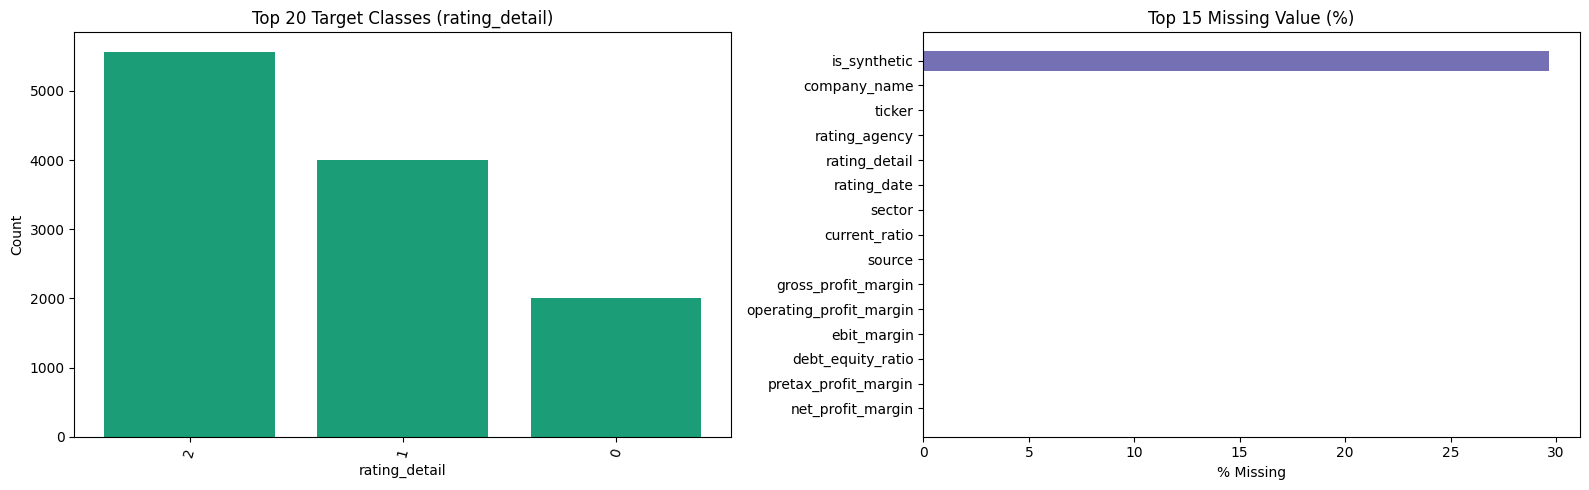

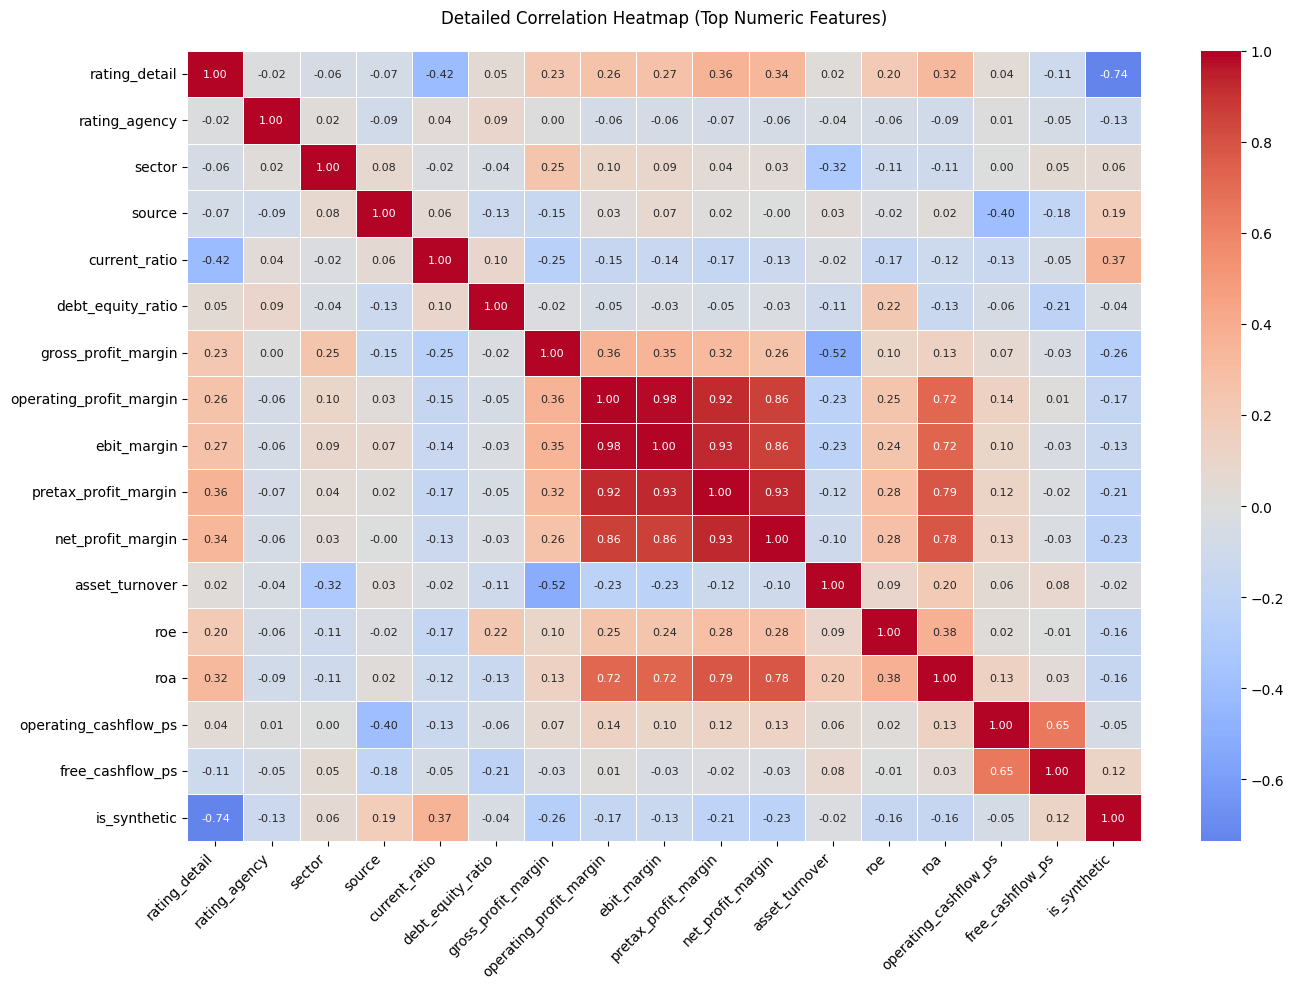

EDA plots (bars and heatmap) saved successfully.


In [ ]:
# 1. Vẽ 2 biểu đồ biểu diễn Bar charts (1 hàng, 2 cột)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Đồ thị 1: Top 20 Target Classes
target_counts = df['rating_detail'].value_counts().sort_values(ascending=False)
axes[0].bar(target_counts.index.astype(str), target_counts.values, color='#1b9e77')
axes[0].set_title('Top 20 Target Classes (rating_detail)')
axes[0].set_xlabel('rating_detail')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=75)

# Đồ thị 2: Top 15 Missing Value (%)
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)
top_missing = missing_pct.head(15)
axes[1].barh(top_missing.index[::-1], top_missing.values[::-1], color='#7570b3')
axes[1].set_title('Top 15 Missing Value (%)')
axes[1].set_xlabel('% Missing')

plt.tight_layout()
plt.savefig(ARTIFACT_DIR / 'eda_bars.png', dpi=150, bbox_inches='tight')
plt.show()

# -----------------------------------------------------------------------------
# 2. Tách riêng biểu đồ Correlation Heatmap
# Lựa chọn 20 features số thực (loại bỏ binary_rating) để quan sát chi tiết nhất vòng Tương quan
num_cols_all = df.select_dtypes(include=[np.number]).columns.tolist()
num_cols_corr = [c for c in num_cols_all if c not in ['binary_rating']][:20] 
corr = df[num_cols_corr].corr()

plt.figure(figsize=(14, 10)) # Định cấu hình ảnh to, dễ review
sns.heatmap(
    corr, 
    cmap='coolwarm', 
    center=0, 
    annot=True,         # Bật chi tiết số liệu correlation trên từng ô
    fmt=".2f",          # Làm tròn 2 chữ số thập phân
    linewidths=0.5,     # Tạo đường lưới mỏng nét cho các ô
    annot_kws={"size": 8} # Thu nhỏ font size số để tránh bị đè nếu chữ quá dài
)
plt.title('Detailed Correlation Heatmap (Top Numeric Features)', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()

plt.savefig(ARTIFACT_DIR / 'eda_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print('EDA plots (bars and heatmap) saved successfully.')


## 3. Target Validation and Feature Preprocessing

Target đã ở dạng số sẵn trong các split; khối này chỉ kiểm tra phạm vi nhãn, xử lý missing values và clip outlier cho các đặc trưng tài chính.

In [7]:
FINANCIAL_FEATURES = [
    'current_ratio', 'debt_equity_ratio',
    'gross_profit_margin', 'operating_profit_margin',
    'ebit_margin', 'pretax_profit_margin',
    'net_profit_margin', 'asset_turnover',
    'roe', 'roa',
    'operating_cashflow_ps', 'free_cashflow_ps'

 ]

SECTOR_COL = 'sector'
SECTOR_UNKNOWN = 'UNKNOWN'
TARGET_COL = 'rating_detail'

# If labels are strings, keep this risk order when available.
TARGET_ORDERED_LABELS = ['Distressed', 'HY', 'IG']

before_rows = len(df)
df = df.dropna(subset=[TARGET_COL]).copy()

target_as_num = pd.to_numeric(df[TARGET_COL], errors='coerce')
if target_as_num.notna().all():
    # Numeric labels path (e.g., 0/1/2). Remap to contiguous IDs from observed classes.
    df[TARGET_COL] = target_as_num.astype(int)
    observed_classes_raw = sorted(df[TARGET_COL].unique().tolist())
    raw_to_id = {int(raw): idx for idx, raw in enumerate(observed_classes_raw)}
    id_to_raw = {idx: int(raw) for raw, idx in raw_to_id.items()}
    df[TARGET_COL] = df[TARGET_COL].map(raw_to_id).astype(int)
else:
    # String labels path (e.g., Distressed/HY/IG).
    target_as_str = df[TARGET_COL].astype(str).str.strip()
    observed_str = sorted(target_as_str.unique().tolist())
    if set(observed_str).issubset(set(TARGET_ORDERED_LABELS)):
        ordered_present = [c for c in TARGET_ORDERED_LABELS if c in observed_str]
    else:
        ordered_present = observed_str
    raw_to_id = {raw: idx for idx, raw in enumerate(ordered_present)}
    id_to_raw = {idx: raw for raw, idx in raw_to_id.items()}
    df[TARGET_COL] = target_as_str.map(raw_to_id).astype(int)

EXPECTED_CLASSES = sorted(df[TARGET_COL].unique().tolist())
if EXPECTED_CLASSES != list(range(len(EXPECTED_CLASSES))):
    raise ValueError(f'Label IDs must be contiguous from 0. Got: {EXPECTED_CLASSES}')

n_classes = len(EXPECTED_CLASSES)
TARGET_MIN, TARGET_MAX = 0, n_classes - 1

# Keep encoder-like metadata object for downstream checkpoint compatibility.
class _StaticLabelEncoder:
    def __init__(self, classes):
        self.classes_ = np.array(classes, dtype=object)

le = _StaticLabelEncoder(classes=[id_to_raw[i] for i in range(n_classes)])

df['rating_date'] = pd.to_datetime(df['rating_date'], format='mixed')

if SECTOR_COL not in df.columns:
    df[SECTOR_COL] = SECTOR_UNKNOWN
df[SECTOR_COL] = df[SECTOR_COL].fillna(SECTOR_UNKNOWN).astype(str).str.strip()
df.loc[df[SECTOR_COL] == '', SECTOR_COL] = SECTOR_UNKNOWN

sector_encoder = LabelEncoder()
df['sector_id'] = sector_encoder.fit_transform(df[SECTOR_COL])
SECTOR_CLASSES = sector_encoder.classes_.tolist()
n_sectors = len(SECTOR_CLASSES)

# Leakage guard: estimate imputation/clipping statistics on train split only.
if '__split__' in df.columns:
    split_series = df['__split__'].astype(str).str.lower()
    train_mask_raw = split_series == 'train'
    has_train_rows = bool(train_mask_raw.any())
else:
    train_mask_raw = pd.Series(False, index=df.index)
    has_train_rows = False

stats_ref = df.loc[train_mask_raw].copy() if has_train_rows else df.copy()

for col in FINANCIAL_FEATURES:
    med = stats_ref[col].median() if stats_ref[col].notna().any() else df[col].median()
    if pd.isna(med):
        med = 0.0
    if df[col].isna().any():
        df[col] = df[col].fillna(float(med))

for col in FINANCIAL_FEATURES:
    lower = stats_ref[col].quantile(0.01)
    upper = stats_ref[col].quantile(0.99)
    if pd.isna(lower) or pd.isna(upper):
        lower = df[col].quantile(0.01)
        upper = df[col].quantile(0.99)
    if pd.isna(lower) or pd.isna(upper):
        continue
    df[col] = df[col].clip(float(lower), float(upper))

print(f'Rows kept after target cleanup: {len(df)} / {before_rows}')
print(f'Number of classes (observed): {n_classes}')
print(f'Label range (model IDs): {TARGET_MIN}..{TARGET_MAX}')
print('Observed label IDs:', sorted(df[TARGET_COL].unique().tolist()))
print('Raw-to-ID mapping:', raw_to_id)
print('Decoder classes (ID -> raw):', le.classes_.tolist())
print(f'Sectors encoded: {n_sectors}')
print(f"Leakage guard reference split: {'train' if has_train_rows else 'all_data_fallback'}")
print('Sample sectors:', SECTOR_CLASSES[:10])
print(f'\nData after preprocessing: {df.shape}')

Rows kept after target cleanup: 10517 / 10517
Number of classes (observed): 3
Label range (model IDs): 0..2
Observed label IDs: [0, 1, 2]
Raw-to-ID mapping: {0: 0, 1: 1, 2: 2}
Decoder classes (ID -> raw): [0, 1, 2]
Sectors encoded: 12
Leakage guard reference split: train
Sample sectors: ['0', '1', '10', '11', '2', '3', '4', '5', '6', '7']

Data after preprocessing: (10517, 22)


## 4. Panel Time-Series Construction

Chuyển dữ liệu về dạng panel theo ticker và timeline để chuẩn bị tạo cửa sổ chuỗi thời gian.

In [ ]:
df_sorted = df.sort_values(['ticker', 'rating_date']).reset_index(drop=True)

panel_df = df_sorted[
    ['ticker', 'rating_date', 'rating_detail', 'sector_id', '__split__'] + FINANCIAL_FEATURES
].copy()
panel_df = panel_df.rename(columns={
    'ticker': 'unique_id',
    'rating_date': 'ds',
    'rating_detail': 'y'
})

ticker_counts = panel_df.groupby('unique_id').size().reset_index(name='count')
print('Ticker count statistics:')
print(ticker_counts['count'].describe())
print()

MIN_HISTORY = 1
valid_tickers = ticker_counts[ticker_counts['count'] >= MIN_HISTORY]['unique_id'].tolist()
panel_df = panel_df[panel_df['unique_id'].isin(valid_tickers)].reset_index(drop=True)

print(f'Tickers with >= {MIN_HISTORY} data points: {len(valid_tickers)}')
print(f'Panel DataFrame shape: {panel_df.shape}')
print(f'Unique tickers: {panel_df["unique_id"].nunique()}')
print(f'Date range: {panel_df["ds"].min()} to {panel_df["ds"].max()}')
print(f'Unique sectors (encoded): {panel_df["sector_id"].nunique()}')
print('Split distribution:')
print(panel_df['__split__'].value_counts())
display(panel_df.head(10))

Ticker count statistics:
count    1206.000000
mean        9.591211
std         7.369865
min         1.000000
25%         4.000000
50%         9.000000
75%        11.000000
max        43.000000
Name: count, dtype: float64

Tickers with >= 1 data points: 1206
Panel DataFrame shape: (11567, 17)
Unique tickers: 1206
Date range: 2005-08-16 00:00:00 to 2016-12-27 00:00:00
Unique sectors (encoded): 12
Split distribution:
__split__
train    8137
val      2250
test     1180
Name: count, dtype: int64


,unique_id,ds,y,sector_id,__split__,current_ratio,debt_equity_ratio,gross_profit_margin,operating_profit_margin,ebit_margin,pretax_profit_margin,net_profit_margin,asset_turnover,roe,roa,operating_cashflow_ps,free_cashflow_ps
0,AA,2015-10-14,1,0,val,-0.712008,-0.234253,-0.968518,-1.122860,-1.203761,-1.175088,-1.421682,-0.150691,-0.547394,-1.808632,1.435162,0.709194
1,AAL,2013-11-12,1,3,train,-0.753091,-4.251423,2.272752,-0.620838,-1.744159,-1.501790,-1.344491,-0.252807,1.402772,-1.648999,1.316342,-2.886685
2,AAL,2015-06-30,1,3,val,-0.947526,2.986584,2.272752,2.312640,2.309767,2.375842,2.368479,-1.445254,3.331284,0.282533,1.345830,-1.080660
3,AAP,2012-06-15,2,6,train,-0.737992,-0.260164,0.254470,-0.168600,-0.155478,0.010862,-0.093115,1.442557,0.876026,0.987221,1.091795,0.488210
4,AAP,2013-05-29,2,6,train,-0.481150,-0.251704,0.261951,-0.182775,-0.169620,-0.005112,-0.106478,0.978379,0.504705,0.590076,-1.251035,-0.615030
5,AAP,2013-09-25,2,6,train,-0.481150,-0.251704,0.261951,-0.182775,-0.169620,-0.005112,-0.106478,0.978379,0.504705,0.590076,-1.251035,-0.615030
6,AAP,2013-11-13,2,6,train,-0.481150,-0.251704,0.261951,-0.182775,-0.169620,-0.005112,-0.106478,0.978379,0.504705,0.590076,-1.251035,-0.615030
7,AAP,2013-11-25,2,6,train,-0.481150,-0.251704,0.261951,-0.182775,-0.169620,-0.005112,-0.106478,0.978379,0.504705,0.590076,-1.251035,-0.615030
8,AAP,2014-02-21,2,6,train,-0.241981,-0.083565,0.268084,-0.216705,-0.203471,-0.037296,-0.126230,0.710111,0.346678,0.360112,-1.373500,-0.315845
9,AAP,2014-06-18,2,6,train,-0.241981,-0.083565,0.268084,-0.216705,-0.203471,-0.037296,-0.126230,0.710111,0.346678,0.360112,-1.373500,-0.315845


## 5. Sliding Windows, Split, and DataLoaders

Tạo mẫu dạng cửa sổ thời gian, chia train/val/test theo nhóm ticker, và khởi tạo DataLoader theo phân phối tự nhiên.

In [ ]:
# Adaptive context length search to maximize usable windows while preserving enough temporal context.
HORIZON = 1
ALLOW_SHORT_TICKER_PADDING = True
WINDOW_PADDING_MODE = 'edge'   # 'edge' or 'zero'

INPUT_SIZE_SEARCH_ENABLED = False
INPUT_SIZE_DEFAULT = 1
INPUT_SIZE_MIN = 0
INPUT_SIZE_MAX = 24
SINGLETON_TICKER_POLICY = 'self_target_padded'
ENABLE_BOOTSTRAP_T0_WINDOW = True
ENABLE_SYNTH_QC = False
ENABLE_WEIGHTED_SAMPLER = True
SAMPLER_WEIGHT_POWER = 0.75


def estimate_window_counts(panel_frame, input_size, horizon=1, allow_short_padding=True):
    """Estimate split-wise window counts for a given input_size using current split labels."""
    counts = {'train': 0, 'val': 0, 'test': 0}
    padded_counts = {'train': 0, 'val': 0, 'test': 0}

    for _, grp in panel_frame.groupby('unique_id'):
        g = grp.sort_values('ds').reset_index(drop=True)
        n = len(g)

        if n < 1:
            continue
        if n < horizon + 1 and not allow_short_padding:
            continue

        if n >= input_size + horizon:
            max_i = n - input_size - horizon + 1
            for i in range(max_i):
                target_idx = i + input_size
                split_label = str(g['__split__'].iloc[target_idx]).lower()
                if split_label in counts:
                    counts[split_label] += 1
        elif allow_short_padding:
            # One padded sample from the latest available target when history is short.
            target_idx = n - 1
            split_label = str(g['__split__'].iloc[target_idx]).lower()
            if split_label in counts:
                counts[split_label] += 1
                padded_counts[split_label] += 1

    total = int(sum(counts.values()))
    total_padded = int(sum(padded_counts.values()))
    return counts, padded_counts, total, total_padded


# Candidate input sizes based on available ticker history.
max_ticker_len = int(ticker_counts['count'].max()) if len(ticker_counts) > 0 else (INPUT_SIZE_DEFAULT + HORIZON)
search_upper = max(INPUT_SIZE_MIN, min(INPUT_SIZE_MAX, max_ticker_len - HORIZON))
input_candidates = list(range(INPUT_SIZE_MIN, search_upper + 1)) if search_upper >= INPUT_SIZE_MIN else [INPUT_SIZE_DEFAULT]
if INPUT_SIZE_DEFAULT not in input_candidates:
    input_candidates.append(INPUT_SIZE_DEFAULT)
input_candidates = sorted(set([int(v) for v in input_candidates if int(v) >= 1]))

search_rows = []
for k in input_candidates:
    est_counts, est_padded, est_total, est_total_padded = estimate_window_counts(
        panel_df,
        input_size=int(k),
        horizon=HORIZON,
        allow_short_padding=ALLOW_SHORT_TICKER_PADDING,
    )
    search_rows.append({
        'input_size': int(k),
        'train_windows': int(est_counts['train']),
        'val_windows': int(est_counts['val']),
        'test_windows': int(est_counts['test']),
        'total_windows': int(est_total),
        'padded_windows_total': int(est_total_padded),
    })

search_df = pd.DataFrame(search_rows).sort_values('input_size').reset_index(drop=True)
if len(search_df) == 0:
    raise ValueError('No valid INPUT_SIZE candidate found for sliding-window construction.')

max_train = float(search_df['train_windows'].max()) if search_df['train_windows'].max() > 0 else 1.0
max_total = float(search_df['total_windows'].max()) if search_df['total_windows'].max() > 0 else 1.0
max_k = float(search_df['input_size'].max()) if search_df['input_size'].max() > 0 else 1.0

# Score balances: train coverage (70%), overall coverage (20%), context length (10%).
search_df['score'] = (
    0.70 * (search_df['train_windows'] / max_train) +
    0.20 * (search_df['total_windows'] / max_total) +
    0.10 * (search_df['input_size'] / max_k)
)

if INPUT_SIZE_SEARCH_ENABLED:
    feasible_df = search_df[
        (search_df['train_windows'] > 0) &
        (search_df['val_windows'] > 0) &
        (search_df['test_windows'] > 0)
    ].copy()

    if len(feasible_df) > 0:
        best_row = feasible_df.sort_values(['score', 'train_windows', 'input_size'], ascending=[False, False, False]).iloc[0]
        INPUT_SIZE = int(best_row['input_size'])
        input_size_reason = 'adaptive_search'
    else:
        INPUT_SIZE = int(np.clip(INPUT_SIZE_DEFAULT, 1, INPUT_SIZE_MAX))
        input_size_reason = 'fallback_default_no_feasible_candidate'
else:
    INPUT_SIZE = int(np.clip(INPUT_SIZE_DEFAULT, 1, INPUT_SIZE_MAX))
    input_size_reason = 'search_disabled'

INPUT_SIZE_SEARCH_REPORT = search_df.copy()

print(f'INPUT_SIZE selected: {INPUT_SIZE} ({input_size_reason})')
print(f'HORIZON (forecast): {HORIZON}')
print(f'Short ticker padding enabled: {ALLOW_SHORT_TICKER_PADDING} ({WINDOW_PADDING_MODE})')
print(f'Singleton ticker policy: {SINGLETON_TICKER_POLICY}')
print('\nTop input-size candidates by score:')
print(
    search_df
    .sort_values(['score', 'train_windows', 'input_size'], ascending=[False, False, False])
    .head(8)
    .to_string(index=False)
)

min_required = INPUT_SIZE + HORIZON
eligible_full_window_tickers = ticker_counts[ticker_counts['count'] >= min_required]['unique_id'].tolist()
panel_df_filtered = panel_df.sort_values(['unique_id', 'ds']).reset_index(drop=True)

print(f'\nTickers with >= {min_required} data points (full windows): {len(eligible_full_window_tickers)}')
print(f'Panel shape (no hard drop by min_required): {panel_df_filtered.shape}')

# -- Feature engineering: add first-order deltas by ticker to capture trend changes --
DELTA_FEATURES = []
for col in FINANCIAL_FEATURES:
    dcol = f'{col}_delta'
    panel_df_filtered[dcol] = (
        panel_df_filtered.groupby('unique_id')[col].diff().fillna(0.0)
    )
    DELTA_FEATURES.append(dcol)

MODEL_FEATURES = FINANCIAL_FEATURES + DELTA_FEATURES

# -- Global scaling (fit on train split only), replacing RevIN normalization --
scaler = RobustScaler()
train_feature_mask = panel_df_filtered['__split__'] == 'train'
if train_feature_mask.any():
    scaler.fit(panel_df_filtered.loc[train_feature_mask, MODEL_FEATURES].values)
else:
    scaler.fit(panel_df_filtered[MODEL_FEATURES].values)
panel_df_filtered[MODEL_FEATURES] = scaler.transform(
    panel_df_filtered[MODEL_FEATURES].values
)

# -- Build sliding window dataset --
class CreditRatingDataset(Dataset):
    """Sliding window dataset.
    Returns X shape (INPUT_SIZE, n_channels), last_y context, and sector_id."""
    def __init__(self, sequences, augment=False, noise_std=0.0, feature_dropout_prob=0.0):
        self.sequences = sequences
        self.augment = augment
        self.noise_std = float(noise_std)
        self.feature_dropout_prob = float(feature_dropout_prob)

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        X, last_y, sector_id, y_target = self.sequences[idx]
        X = np.asarray(X, dtype=np.float32).copy()

        if self.augment:
            if self.noise_std > 0:
                X += np.random.normal(0.0, self.noise_std, size=X.shape).astype(np.float32)
            if self.feature_dropout_prob > 0:
                drop_mask = np.random.rand(X.shape[1]) < self.feature_dropout_prob
                if drop_mask.any():
                    X[:, drop_mask] = 0.0

        return (
            torch.tensor(X, dtype=torch.float32),
            torch.tensor(last_y, dtype=torch.long),
            torch.tensor(sector_id, dtype=torch.long),
            torch.tensor(y_target, dtype=torch.long),
        )


def build_padded_window(values, target_idx, input_size, mode='edge'):
    """Build fixed-length window ending right before target_idx with optional left padding."""
    if values.shape[0] == 0:
        return None

    # For singleton tickers, fallback to the first row as minimal context.
    if target_idx <= 0:
        X_raw = values[:1]
    else:
        start_idx = max(0, target_idx - input_size)
        X_raw = values[start_idx:target_idx]

    if X_raw.shape[0] == 0:
        X_raw = values[:1]

    if X_raw.shape[0] >= input_size:
        return X_raw[-input_size:]

    pad_len = input_size - X_raw.shape[0]
    if mode == 'zero':
        pad_block = np.zeros((pad_len, X_raw.shape[1]), dtype=X_raw.dtype)
    else:
        pad_block = np.repeat(X_raw[[0]], pad_len, axis=0)

    return np.concatenate([pad_block, X_raw], axis=0)


feature_cols = MODEL_FEATURES
n_channels = len(feature_cols)

train_seqs = []
val_seqs = []
test_seqs = []
test_seq_tickers = []
train_seq_is_synth = []
train_seq_is_change = []
has_synth_col = 'is_synthetic' in panel_df_filtered.columns

short_seq_windows_added = 0
singleton_windows_added = 0
bootstrap_t0_windows_added = 0
short_seq_tickers_used = set()

for uid, grp in panel_df_filtered.groupby('unique_id'):
    grp = grp.sort_values('ds').reset_index(drop=True)
    values = grp[feature_cols].values  # (T, C)
    n = len(values)

    if n == 0:
        continue

    if ENABLE_BOOTSTRAP_T0_WINDOW and n >= INPUT_SIZE + HORIZON:
        # Add one extra sample at the first timestamp to maximize train coverage.
        target_idx = 0
        X0 = build_padded_window(values, target_idx=target_idx, input_size=INPUT_SIZE, mode=WINDOW_PADDING_MODE)
        if X0 is not None and X0.shape[0] == INPUT_SIZE:
            last_y0 = int(grp['y'].iloc[target_idx])
            y_target0 = int(grp['y'].iloc[target_idx])
            sector_id0 = int(grp['sector_id'].iloc[target_idx])
            split_label0 = str(grp['__split__'].iloc[target_idx]).lower()

            sample0 = (X0, last_y0, sector_id0, y_target0)
            if split_label0 == 'test':
                test_seqs.append(sample0)
                test_seq_tickers.append(uid)
            elif split_label0 == 'val':
                val_seqs.append(sample0)
            else:
                train_seqs.append(sample0)
                train_seq_is_change.append(int(y_target0 != last_y0))
                if has_synth_col:
                    train_seq_is_synth.append(int(grp['is_synthetic'].iloc[target_idx]))
                else:
                    train_seq_is_synth.append(0)

            bootstrap_t0_windows_added += 1
    if n < HORIZON + 1 and not ALLOW_SHORT_TICKER_PADDING:
        continue

    if n < INPUT_SIZE + HORIZON and ALLOW_SHORT_TICKER_PADDING:
        # Keep short ticker (including n=1) by creating one padded window.
        target_idx = n - 1
        X = build_padded_window(values, target_idx=target_idx, input_size=INPUT_SIZE, mode=WINDOW_PADDING_MODE)
        if X is not None and X.shape[0] == INPUT_SIZE:
            last_y_idx = max(0, target_idx - 1)
            last_y = int(grp['y'].iloc[last_y_idx])
            y_target = int(grp['y'].iloc[target_idx])
            sector_id = int(grp['sector_id'].iloc[target_idx])
            split_label = str(grp['__split__'].iloc[target_idx]).lower()

            sample = (X, last_y, sector_id, y_target)
            if split_label == 'test':
                test_seqs.append(sample)
                test_seq_tickers.append(uid)
            elif split_label == 'val':
                val_seqs.append(sample)
            else:
                train_seqs.append(sample)
                train_seq_is_change.append(int(y_target != last_y))
                if has_synth_col:
                    train_seq_is_synth.append(int(grp['is_synthetic'].iloc[target_idx]))
                else:
                    train_seq_is_synth.append(0)

            short_seq_windows_added += 1
            if n == 1:
                singleton_windows_added += 1
            short_seq_tickers_used.add(uid)
        continue

    for i in range(n - INPUT_SIZE - HORIZON + 1):
        X = values[i : i + INPUT_SIZE]
        last_y = int(grp['y'].iloc[i + INPUT_SIZE - 1])
        target_idx = i + INPUT_SIZE
        y_target = int(grp['y'].iloc[target_idx])  # next-step class
        sector_id = int(grp['sector_id'].iloc[target_idx])
        split_label = str(grp['__split__'].iloc[target_idx]).lower()

        sample = (X, last_y, sector_id, y_target)
        if split_label == 'test':
            test_seqs.append(sample)
            test_seq_tickers.append(uid)
        elif split_label == 'val':
            val_seqs.append(sample)
        else:
            train_seqs.append(sample)
            train_seq_is_change.append(int(y_target != last_y))
            if has_synth_col:
                train_seq_is_synth.append(int(grp['is_synthetic'].iloc[target_idx]))
            else:
                train_seq_is_synth.append(0)

train_tickers = set(
    panel_df_filtered.loc[panel_df_filtered['__split__'] == 'train', 'unique_id'].tolist()
)
val_tickers = set(
    panel_df_filtered.loc[panel_df_filtered['__split__'] == 'val', 'unique_id'].tolist()
)

if len(train_seqs) == 0 or len(val_seqs) == 0 or len(test_seqs) == 0:
    raise ValueError(
        f'Empty split sequences found: train={len(train_seqs)}, val={len(val_seqs)}, test={len(test_seqs)}. '
        'Please check split files and time-order windows.'
    )

test_seq_tickers = np.array(test_seq_tickers, dtype=object)
train_seq_is_synth = np.array(train_seq_is_synth, dtype=int)
train_seq_is_change = np.array(train_seq_is_change, dtype=int)

# -- Synthetic sequence quality control and ratio cap --
SYNTH_MAX_ABS_FEATURE = 4.0
SYNTH_MAX_RATIO = 0.20
train_seqs_before_synth_qc = len(train_seqs)
if ENABLE_SYNTH_QC and has_synth_col and len(train_seqs) > 0:
    seq_max_abs = np.array([float(np.max(np.abs(s[0]))) for s in train_seqs], dtype=np.float32)
    keep_mask = np.ones(len(train_seqs), dtype=bool)
    synth_mask = train_seq_is_synth == 1

    # Remove synthetic windows with extreme amplitudes (often unrealistic).
    keep_mask[synth_mask & (seq_max_abs > SYNTH_MAX_ABS_FEATURE)] = False

    # Cap remaining synthetic ratio to reduce domain shift from generated data.
    kept_synth_idx = np.where(keep_mask & synth_mask)[0]
    kept_real_idx = np.where(keep_mask & (~synth_mask))[0]
    max_synth_keep = int(len(kept_real_idx) * SYNTH_MAX_RATIO / max(1e-9, 1.0 - SYNTH_MAX_RATIO))
    if len(kept_synth_idx) > max_synth_keep > 0:
        rng_seq = np.random.default_rng(SEED)
        drop_idx = rng_seq.choice(
            kept_synth_idx,
            size=len(kept_synth_idx) - max_synth_keep,
            replace=False,
        )
        keep_mask[drop_idx] = False

    if not keep_mask.all():
        train_seqs = [s for s, k in zip(train_seqs, keep_mask) if k]
        train_seq_is_synth = train_seq_is_synth[keep_mask]
        train_seq_is_change = train_seq_is_change[keep_mask]
train_seqs_after_synth_qc = len(train_seqs)

# Temporarily disable sequence-level regularization to test model capacity/underfit.
TRAIN_WINDOW_NOISE_STD = 0.01  # Reduced from 0.02 for training stability
TRAIN_FEATURE_DROPOUT = 0.03  # Reduced from 0.05 to close train/val loss gap

train_ds = CreditRatingDataset(
    train_seqs,
    augment=True,
    noise_std=TRAIN_WINDOW_NOISE_STD,
    feature_dropout_prob=TRAIN_FEATURE_DROPOUT,
)
val_ds = CreditRatingDataset(val_seqs, augment=False)
test_ds = CreditRatingDataset(test_seqs, augment=False)

# Simplified: no sampler re-weight; keep natural training distribution.
train_labels = np.array([s[3] for s in train_seqs], dtype=int)
class_freq_raw = np.bincount(train_labels, minlength=n_classes).astype(float)
non_zero_freq = class_freq_raw[class_freq_raw > 0]
imbalance_ratio = (
    float(class_freq_raw.max() / non_zero_freq.min())
    if len(non_zero_freq) > 0 else 1.0
)
synthetic_ratio_train = float(train_seq_is_synth.mean()) if len(train_seq_is_synth) > 0 else 0.0
transition_ratio_train = float(train_seq_is_change.mean()) if len(train_seq_is_change) > 0 else 0.0
weighted_sampler = None
if ENABLE_WEIGHTED_SAMPLER and len(train_labels) > 0:
    class_weights = np.zeros_like(class_freq_raw, dtype=np.float64)
    non_zero_mask = class_freq_raw > 0
    class_weights[non_zero_mask] = class_freq_raw[non_zero_mask].sum() / class_freq_raw[non_zero_mask]
    sample_weights = np.power(class_weights[train_labels], SAMPLER_WEIGHT_POWER)
    weighted_sampler = torch.utils.data.WeightedRandomSampler(
        weights=torch.as_tensor(sample_weights, dtype=torch.double),
        num_samples=len(sample_weights),
        replacement=True,
    )

BATCH_SIZE = 64  # Increased from 32 for more stable gradients
NUM_WORKERS = 4 if IN_KAGGLE else 0
PIN_MEMORY = torch.cuda.is_available()

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=(weighted_sampler is None),
    sampler=weighted_sampler,
    drop_last=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)
test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)

print(f'\nChannels: {n_channels}')
print(f'Base features: {len(FINANCIAL_FEATURES)} | Delta features: {len(DELTA_FEATURES)}')
print(f'Train tickers: {len(train_tickers)} | Val tickers: {len(val_tickers)}')
print(f'Train samples: {len(train_ds)}')
print(f'Val samples:   {len(val_ds)}')
print(f'Test samples:  {len(test_ds)}')
print(f'Test ticker refs: {len(test_seq_tickers)}')
print(f'Short padded windows added: {short_seq_windows_added} (tickers: {len(short_seq_tickers_used)})')
print(f'Singleton (n=1) windows kept via padding: {singleton_windows_added}')
print(f'Bootstrap t0 windows added: {bootstrap_t0_windows_added}')
print(f'Synth QC enabled: {ENABLE_SYNTH_QC} | removed windows: {train_seqs_before_synth_qc - train_seqs_after_synth_qc}')
print(f'Train synthetic ratio (windows): {synthetic_ratio_train:.3f}')
print(f'Train transition ratio (y_t+1 != y_t): {transition_ratio_train:.3f}')
print(f'Train class freq min/max: {class_freq_raw.min():.0f}/{class_freq_raw.max():.0f}')
print(f'Imbalance ratio (max/min non-zero): {imbalance_ratio:.2f}')
print(f'Weighted sampler enabled: {weighted_sampler is not None}')
print(f'Sampler weight power: {SAMPLER_WEIGHT_POWER}')
print(f'Train window noise std: {TRAIN_WINDOW_NOISE_STD}')
print(f'Train feature dropout prob: {TRAIN_FEATURE_DROPOUT}')

# Verify shape
sample_X, sample_last_y, sample_sector_id, sample_y = train_ds[0]
print(f'\nSample X shape: {sample_X.shape}  (T, C)')
print(f'Sample last_y: {sample_last_y}')
print(f'Sample sector_id: {sample_sector_id}')
print(f'Sample y: {sample_y}')

INPUT_SIZE selected: 1 (search_disabled)
HORIZON (forecast): 1
Short ticker padding enabled: True (edge)
Singleton ticker policy: self_target_padded

Top input-size candidates by score:
 input_size  train_windows  val_windows  test_windows  total_windows  padded_windows_total    score
          1           7109         2202          1155          10466                   105 0.904167
          2           6170         2137          1134           9441                   181 0.796286
          3           5324         2068          1110           8502                   267 0.699206
          4           4565         1976          1077           7618                   322 0.611743
          5           3869         1894          1037           6800                   388 0.531746
          6           3206         1842          1000           6048                   454 0.456259
          7           2568         1786           979           5333                   491 0.383940
          8   

In [ ]:
# ============================================================
# Deterministic DataLoader Rebuild (stability/reproducibility)
# ============================================================

def seed_worker(worker_id):
    worker_seed = SEED + worker_id
    np.random.seed(worker_seed)
    random.seed(worker_seed)

loader_generator = torch.Generator()
loader_generator.manual_seed(SEED)

weighted_sampler = None
if ENABLE_WEIGHTED_SAMPLER and len(train_labels) > 0:
    class_weights = np.zeros_like(class_freq_raw, dtype=np.float64)
    non_zero_mask = class_freq_raw > 0
    class_weights[non_zero_mask] = class_freq_raw[non_zero_mask].sum() / class_freq_raw[non_zero_mask]
    sample_weights = np.power(class_weights[train_labels], SAMPLER_WEIGHT_POWER)
    weighted_sampler = torch.utils.data.WeightedRandomSampler(
        weights=torch.as_tensor(sample_weights, dtype=torch.double),
        num_samples=len(sample_weights),
        replacement=True,
        generator=loader_generator,
    )

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=(weighted_sampler is None),
    sampler=weighted_sampler,
    drop_last=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    worker_init_fn=seed_worker if NUM_WORKERS > 0 else None,
    persistent_workers=bool(NUM_WORKERS > 0),
    generator=loader_generator if weighted_sampler is None else None,
 )

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    worker_init_fn=seed_worker if NUM_WORKERS > 0 else None,
    persistent_workers=bool(NUM_WORKERS > 0),
    generator=loader_generator,
 )

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    worker_init_fn=seed_worker if NUM_WORKERS > 0 else None,
    persistent_workers=bool(NUM_WORKERS > 0),
    generator=loader_generator,
 )

print('Rebuilt DataLoaders with deterministic generator and worker seeding.')
print(f'Weighted sampler enabled: {weighted_sampler is not None}')
print(f'Persistent workers: {bool(NUM_WORKERS > 0)}')

Rebuilt DataLoaders with deterministic generator and worker seeding.
Weighted sampler enabled: True
Persistent workers: True


## 6. Loss Function and Class-Imbalance Handling

Định nghĩa Focal Loss và class weights để tăng độ ổn định khi dữ liệu mất cân bằng.

In [ ]:
def build_effective_num_class_weights(class_counts, beta=0.995):
    """Effective-number reweighting (Cui et al.) with mean=1 normalization."""
    counts = np.asarray(class_counts, dtype=np.float64)
    counts = np.maximum(counts, 0.0)
    weights = np.zeros_like(counts, dtype=np.float64)

    valid = counts > 0
    if valid.any():
        effective_num = 1.0 - np.power(float(beta), counts[valid])
        weights[valid] = (1.0 - float(beta)) / np.maximum(effective_num, 1e-12)
        weights[valid] = weights[valid] / np.mean(weights[valid])
    else:
        weights[:] = 1.0
    return weights


class FocalOrdinalLoss(nn.Module):
    """Focal loss + ordinal distance regularization with optional class-balance weights."""
    def __init__(self, n_classes, gamma=1.5, ordinal_alpha=0.04, label_smoothing=0.0, class_weights=None):
        super().__init__()
        self.n_classes = int(n_classes)
        self.gamma = float(gamma)
        self.ordinal_alpha = float(ordinal_alpha)
        self.label_smoothing = float(label_smoothing)
        if class_weights is None:
            self.class_weights = None
        else:
            cw = torch.tensor(class_weights, dtype=torch.float32)
            self.register_buffer('class_weights', cw)

    def forward(self, logits, targets):
        # Keep CE computation in FP32 and move class weights to the same device as logits.
        logits_for_loss = logits.float()
        weight = None
        if self.class_weights is not None:
            weight = self.class_weights.to(device=logits.device, dtype=torch.float32)

        ce_loss = F.cross_entropy(
            logits_for_loss,
            targets,
            reduction='none',
            weight=weight,
            label_smoothing=self.label_smoothing,
        )
        pt = torch.exp(-ce_loss)
        focal_ce = ((1.0 - pt) ** self.gamma) * ce_loss
        focal_ce = focal_ce.mean()

        probs = F.softmax(logits_for_loss, dim=-1)
        classes = torch.arange(self.n_classes, device=logits.device, dtype=probs.dtype)
        expected_class = torch.sum(probs * classes.unsqueeze(0), dim=-1)
        dist_loss = F.mse_loss(expected_class, targets.float())

        return focal_ce + self.ordinal_alpha * dist_loss


CLASS_BALANCE_BETA = 0.995
class_weights_effective = build_effective_num_class_weights(
    class_freq_raw if 'class_freq_raw' in globals() else np.ones(n_classes),
    beta=CLASS_BALANCE_BETA,
 )

criterion_settings = {
    'loss_name': 'focal_ordinal_class_balanced',
    'focal_gamma': 1.5,
    'label_smoothing': 0.00,
    'ordinal_alpha': 0.04,
    'class_balance_beta': CLASS_BALANCE_BETA,
}

criterion = FocalOrdinalLoss(
    n_classes=n_classes,
    gamma=criterion_settings['focal_gamma'],
    ordinal_alpha=criterion_settings['ordinal_alpha'],
    label_smoothing=criterion_settings['label_smoothing'],
    class_weights=class_weights_effective,
).to(device)

FOCAL_GAMMA = criterion_settings['focal_gamma']
print(
    f"Loss: {criterion_settings['loss_name']} | "
    f"gamma={criterion_settings['focal_gamma']} | "
    f"smoothing={criterion_settings['label_smoothing']} | "
    f"ordinal_alpha={criterion_settings['ordinal_alpha']} | "
    f"beta={criterion_settings['class_balance_beta']}"
 )
print('Effective class weights:', np.round(class_weights_effective, 4).tolist())

Loss: focal_ordinal_class_balanced | gamma=1.5 | smoothing=0.0 | ordinal_alpha=0.04 | beta=0.995
Effective class weights: [1.0001, 1.0, 1.0]


## 7. TLSTM-Fuzzy Model Definition

Khai báo các thành phần FuzzyLayer, Transformer block, LSTM, sector embedding và head phân loại.

In [ ]:
class FuzzyLayer(nn.Module):
    """Gaussian fuzzy membership expansion with configurable MFs per feature."""
    def __init__(self, input_features, n_mfs=5, init_sigma=1.0):
        super().__init__()
        self.input_features = input_features
        self.n_mfs = n_mfs
        self.centers = nn.Parameter(torch.linspace(-1.0, 1.0, n_mfs).repeat(input_features, 1))
        self.log_sigma = nn.Parameter(torch.full((input_features, n_mfs), math.log(init_sigma)))

    def forward(self, x):
        # x: (B, T, F)
        x_exp = x.unsqueeze(-1)
        centers = self.centers.unsqueeze(0).unsqueeze(0)
        sigma = torch.exp(self.log_sigma).unsqueeze(0).unsqueeze(0).clamp(min=1e-3)
        memberships = torch.exp(-0.5 * ((x_exp - centers) / sigma) ** 2)
        return memberships.reshape(x.shape[0], x.shape[1], self.input_features * self.n_mfs)


class TemporalSelfAttentionBlock(nn.Module):
    """Pre-norm Transformer block with learnable relative positional bias."""
    def __init__(self, d_model=128, n_heads=4, dropout=0.1, max_relative_position=32):
        super().__init__()
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.attn = nn.MultiheadAttention(
            embed_dim=d_model,
            num_heads=n_heads,
            dropout=dropout,
            batch_first=True,
        )
        self.dropout = nn.Dropout(dropout)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, 4 * d_model),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(4 * d_model, d_model),
        )
        self.max_relative_position = int(max_relative_position)
        self.relative_bias = nn.Parameter(torch.zeros(2 * self.max_relative_position + 1))

    def _relative_bias_matrix(self, seq_len, device, dtype):
        pos = torch.arange(seq_len, device=device)
        rel = pos[None, :] - pos[:, None]
        rel = rel.clamp(-self.max_relative_position, self.max_relative_position)
        rel = rel + self.max_relative_position
        return self.relative_bias[rel].to(dtype=dtype)

    def forward(self, x):
        x_norm = self.norm1(x)
        attn_bias = self._relative_bias_matrix(x.size(1), x.device, x.dtype)
        attn_out, _ = self.attn(
            x_norm,
            x_norm,
            x_norm,
            attn_mask=attn_bias,
            need_weights=False,
        )
        x = x + self.dropout(attn_out)
        x = x + self.dropout(self.ffn(self.norm2(x)))
        return x


class AttentivePool(nn.Module):
    """Learnable weighted pooling over temporal axis."""
    def __init__(self, dim):
        super().__init__()
        self.score = nn.Sequential(
            nn.Linear(dim, dim),
            nn.Tanh(),
            nn.Linear(dim, 1),
        )

    def forward(self, x):
        w = torch.softmax(self.score(x), dim=1)
        ctx = (w * x).sum(dim=1)
        return ctx, w


class TLSTMFuzzyClassifier(nn.Module):
    """Transformer-LSTM + Fuzzy classifier with sector embedding + transition head."""
    def __init__(
        self,
        n_channels,
        n_classes,
        n_sectors,
        hidden_size=128,
        dropout=0.10,
        n_mfs=5,
        d_model=128,
        n_heads=4,
        n_layers=3,
        sector_emb_dim=16,
        max_relative_position=32,
    ):
        super().__init__()
        self.fuzzy = FuzzyLayer(n_channels, n_mfs=n_mfs)

        fuzzy_dim = n_channels * n_mfs
        self.input_proj = nn.Sequential(
            nn.Linear(fuzzy_dim, d_model),
            nn.GELU(),
            nn.Dropout(dropout * 0.5),
        )

        self.blocks = nn.ModuleList([
            TemporalSelfAttentionBlock(
                d_model=d_model,
                n_heads=n_heads,
                dropout=dropout,
                max_relative_position=max_relative_position,
            )
            for _ in range(n_layers)
        ])

        self.pre_lstm_norm = nn.LayerNorm(d_model)
        self.lstm = nn.LSTM(
            input_size=d_model,
            hidden_size=hidden_size,
            batch_first=True,
            bidirectional=True,
        )
        self.attn_pool = AttentivePool(hidden_size * 2)
        self.last_y_embed = nn.Embedding(n_classes, hidden_size)
        self.sector_embed = nn.Embedding(n_sectors, sector_emb_dim)

        transition_in_dim = hidden_size * 2 + sector_emb_dim
        self.transition_head = nn.Sequential(
            nn.Linear(transition_in_dim, hidden_size),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size, 1),
        )

        head_in_dim = hidden_size * 3 + sector_emb_dim
        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(head_in_dim, hidden_size * 2),
            nn.GELU(),
            nn.Dropout(dropout * 0.8),
            nn.Linear(hidden_size * 2, n_classes),
        )

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Embedding):
                nn.init.normal_(m.weight, mean=0.0, std=0.02)

    def forward(self, x, last_y, sector_id, return_aux=False):
        x_fuzzy = self.fuzzy(x)
        x_embed = self.input_proj(x_fuzzy)

        for blk in self.blocks:
            x_embed = blk(x_embed)

        x_embed = self.pre_lstm_norm(x_embed)
        lstm_out, _ = self.lstm(x_embed)
        seq_ctx, _ = self.attn_pool(lstm_out)

        last_y_emb = self.last_y_embed(last_y)
        sector_emb = self.sector_embed(sector_id)

        transition_logits = self.transition_head(torch.cat([seq_ctx, sector_emb], dim=-1)).squeeze(-1)

        out = torch.cat([seq_ctx, last_y_emb, sector_emb], dim=-1)
        logits = self.head(out)

        if return_aux:
            return logits, transition_logits
        return logits


FUZZY_MFS = 5
MODEL_D_MODEL = 128
TRANSFORMER_HEADS = 4
TRANSFORMER_LAYERS = 3
LSTM_HIDDEN = 128
SECTOR_EMB_DIM = 16
TLSTM_DROPOUT = 0.10
MAX_RELATIVE_POSITION = 32

model = TLSTMFuzzyClassifier(
    n_channels=n_channels,
    n_classes=n_classes,
    n_sectors=n_sectors,
    hidden_size=LSTM_HIDDEN,
    dropout=TLSTM_DROPOUT,
    n_mfs=FUZZY_MFS,
    d_model=MODEL_D_MODEL,
    n_heads=TRANSFORMER_HEADS,
    n_layers=TRANSFORMER_LAYERS,
    sector_emb_dim=SECTOR_EMB_DIM,
    max_relative_position=MAX_RELATIVE_POSITION,
).to(device)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Fuzzy MFs per feature: {FUZZY_MFS}')
print(f'Projected d_model: {MODEL_D_MODEL}')
print(f'Transformer layers/heads: {TRANSFORMER_LAYERS}/{TRANSFORMER_HEADS}')
print(f'Relative position window: +/-{MAX_RELATIVE_POSITION}')
print(f'BiLSTM hidden size: {LSTM_HIDDEN}')
print(f'Sector embedding dim: {SECTOR_EMB_DIM}')
print(f'Channels: {n_channels} (base + delta features)')
print(f'Sectors: {n_sectors}')
print(f'Model parameters: {n_params:,}')
print('\nTLSTM-Fuzzy model created successfully!')
print(model)

Fuzzy MFs per feature: 5
Projected d_model: 128
Transformer layers/heads: 3/4
Relative position window: +/-32
BiLSTM hidden size: 128
Sector embedding dim: 16
Channels: 24 (base + delta features)
Sectors: 12
Model parameters: 1,080,312

TLSTM-Fuzzy model created successfully!
TLSTMFuzzyClassifier(
  (fuzzy): FuzzyLayer()
  (input_proj): Sequential(
    (0): Linear(in_features=120, out_features=128, bias=True)
    (1): GELU(approximate='none')
    (2): Dropout(p=0.05, inplace=False)
  )
  (blocks): ModuleList(
    (0-2): 3 x TemporalSelfAttentionBlock(
      (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (attn): MultiheadAttention(
        (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
      )
      (dropout): Dropout(p=0.1, inplace=False)
      (ffn): Sequential(
        (0): Linear(in_features=128, out_features=512, bias=True)
        (1): GELU(approxim

In [ ]:
# ============================================================
# Lightweight Hyperparameter Search (val_f1_weighted)
# ============================================================
from torch.utils.data import Subset


def build_training_criterion(config, n_classes):
    beta = float(config.get('class_balance_beta', globals().get('CLASS_BALANCE_BETA', 0.995)))
    counts = globals().get('class_freq_raw', np.ones(n_classes, dtype=float))
    class_weights = build_effective_num_class_weights(counts, beta=beta)
    return FocalOrdinalLoss(
        n_classes=n_classes,
        gamma=float(config.get('focal_gamma', 1.5)),
        ordinal_alpha=float(config.get('ordinal_alpha', 0.02)),
        label_smoothing=float(config.get('label_smoothing', 0.0)),
        class_weights=class_weights,
    )


def run_quick_trial(config, train_subset_loader, val_subset_loader, n_epochs=8, patience=3):
    trial_model = TLSTMFuzzyClassifier(
        n_channels=n_channels,
        n_classes=n_classes,
        n_sectors=n_sectors,
        hidden_size=int(config['hidden_size']),
        dropout=float(config['dropout']),
        n_mfs=int(config['fuzzy_mfs']),
        d_model=int(config['d_model']),
        n_heads=int(config['n_heads']),
        n_layers=int(config['n_layers']),
        sector_emb_dim=int(config['sector_emb_dim']),
        max_relative_position=int(config.get('max_relative_position', 32)),
    ).to(device)

    trial_criterion = build_training_criterion(config, n_classes=n_classes).to(device)
    trial_optimizer = torch.optim.AdamW(
        trial_model.parameters(),
        lr=float(config['lr']),
        weight_decay=float(config['weight_decay']),
    )

    steps_per_epoch = max(1, len(train_subset_loader))
    trial_scheduler = torch.optim.lr_scheduler.OneCycleLR(
        trial_optimizer,
        max_lr=float(config['max_lr']),
        steps_per_epoch=steps_per_epoch,
        epochs=n_epochs,
        pct_start=0.2,
        anneal_strategy='cos',
        div_factor=max(float(config['max_lr']) / float(config['lr']), 1.0),
        final_div_factor=100.0,
    )

    amp_enabled_local = torch.cuda.is_available()
    amp_device_local = 'cuda' if amp_enabled_local else 'cpu'
    scaler_local = torch.amp.GradScaler(amp_device_local, enabled=amp_enabled_local)

    best_f1w = -np.inf
    no_improve = 0

    for _ in range(n_epochs):
        trial_model.train()
        for X_batch, last_y_batch, sector_batch, y_batch in train_subset_loader:
            X_batch = X_batch.to(device)
            last_y_batch = last_y_batch.to(device)
            sector_batch = sector_batch.to(device)
            y_batch = y_batch.to(device)

            trial_optimizer.zero_grad(set_to_none=True)
            with torch.amp.autocast(device_type=amp_device_local, enabled=amp_enabled_local):
                logits = trial_model(X_batch, last_y_batch, sector_batch)
                loss = trial_criterion(logits, y_batch)

            scaler_local.scale(loss).backward()
            scaler_local.unscale_(trial_optimizer)
            torch.nn.utils.clip_grad_norm_(trial_model.parameters(), 1.0)
            scaler_local.step(trial_optimizer)
            scaler_local.update()
            trial_scheduler.step()

        trial_model.eval()
        val_pred, val_true = [], []
        with torch.no_grad():
            for X_batch, last_y_batch, sector_batch, y_batch in val_subset_loader:
                X_batch = X_batch.to(device)
                last_y_batch = last_y_batch.to(device)
                sector_batch = sector_batch.to(device)
                logits = trial_model(X_batch, last_y_batch, sector_batch)
                pred = logits.argmax(dim=1).cpu().numpy()
                val_pred.extend(pred.tolist())
                val_true.extend(y_batch.numpy().tolist())

        f1w = f1_score(val_true, val_pred, average='weighted', zero_division=0)
        if f1w > best_f1w + 1e-4:
            best_f1w = f1w
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                break

    return float(best_f1w)


RUN_HYPERPARAM_SEARCH = False
TUNE_MAX_TRIALS = 12
TUNE_EPOCHS = 6
TUNE_PATIENCE = 2
TUNE_BATCH_SIZE = 64
TUNE_TRAIN_FRACTION = 0.5
TUNE_VAL_FRACTION = 1.0

base_config = {
    'hidden_size': 128,
    'dropout': 0.10,
    'fuzzy_mfs': 5,
    'd_model': 128,
    'n_heads': 4,
    'n_layers': 3,
    'sector_emb_dim': 16,
    'max_relative_position': 32,
    'lr': 3e-4,
    'max_lr': 1.0e-3,
    'weight_decay': 8e-4,
    'focal_gamma': 1.5,
    'ordinal_alpha': 0.02,
    'label_smoothing': 0.01,
    'class_balance_beta': 0.995,
    'aux_transition_weight': 0.10,
    'aux_transition_weight_min': 0.03,
    'aux_transition_start_frac': 0.10,
}

search_space = {
    'hidden_size': [64, 128],
    'dropout': [0.08, 0.10, 0.12],
    'fuzzy_mfs': [5, 7],
    'd_model': [128, 256],
    'n_heads': [4, 8],
    'n_layers': [3, 4],
    'sector_emb_dim': [16, 32],
    'max_relative_position': [16, 32],
    'lr': [2e-4, 3e-4, 5e-4],
    'max_lr': [8.0e-4, 1.0e-3, 1.2e-3],
    'weight_decay': [5e-4, 8e-4, 1e-3],
    'focal_gamma': [1.0, 1.5, 2.0],
    'ordinal_alpha': [0.01, 0.02, 0.04],
    'label_smoothing': [0.0, 0.01],
}

if RUN_HYPERPARAM_SEARCH:
    train_size = len(train_ds)
    val_size = len(val_ds)
    n_train_sub = max(256, int(train_size * TUNE_TRAIN_FRACTION))
    n_val_sub = max(256, int(val_size * TUNE_VAL_FRACTION))

    rng = np.random.default_rng(SEED)
    train_idx = rng.choice(train_size, size=min(train_size, n_train_sub), replace=False)
    val_idx = rng.choice(val_size, size=min(val_size, n_val_sub), replace=False)

    train_sub_ds = Subset(train_ds, train_idx.tolist())
    val_sub_ds = Subset(val_ds, val_idx.tolist())

    train_sub_loader = DataLoader(
        train_sub_ds,
        batch_size=TUNE_BATCH_SIZE,
        shuffle=True,
        num_workers=0,
        pin_memory=torch.cuda.is_available(),
    )
    val_sub_loader = DataLoader(
        val_sub_ds,
        batch_size=TUNE_BATCH_SIZE,
        shuffle=False,
        num_workers=0,
        pin_memory=torch.cuda.is_available(),
    )

    all_candidates = []
    for hs in search_space['hidden_size']:
        for dr in search_space['dropout']:
            for mfs in search_space['fuzzy_mfs']:
                for dm in search_space['d_model']:
                    for nh in search_space['n_heads']:
                        if dm % nh != 0:
                            continue
                        for nl in search_space['n_layers']:
                            for se in search_space['sector_emb_dim']:
                                for mrp in search_space['max_relative_position']:
                                    for lr in search_space['lr']:
                                        for max_lr in search_space['max_lr']:
                                            if max_lr <= lr:
                                                continue
                                            for wd in search_space['weight_decay']:
                                                for gamma in search_space['focal_gamma']:
                                                    for ord_alpha in search_space['ordinal_alpha']:
                                                        for smooth in search_space['label_smoothing']:
                                                            all_candidates.append({
                                                                'hidden_size': hs,
                                                                'dropout': dr,
                                                                'fuzzy_mfs': mfs,
                                                                'd_model': dm,
                                                                'n_heads': nh,
                                                                'n_layers': nl,
                                                                'sector_emb_dim': se,
                                                                'max_relative_position': mrp,
                                                                'lr': lr,
                                                                'max_lr': max_lr,
                                                                'weight_decay': wd,
                                                                'focal_gamma': gamma,
                                                                'ordinal_alpha': ord_alpha,
                                                                'label_smoothing': smooth,
                                                                'class_balance_beta': 0.995,
                                                            })

    perm = rng.permutation(len(all_candidates))
    selected = [all_candidates[i] for i in perm[:min(TUNE_MAX_TRIALS, len(all_candidates))]]

    best_cfg = dict(base_config)
    best_score = -np.inf
    tune_results = []

    print(f'Running hyperparameter search on {len(selected)} trials...')
    print(f'Train subset: {len(train_sub_ds)} | Val subset: {len(val_sub_ds)}')

    for t, cfg in enumerate(selected, start=1):
        score = run_quick_trial(
            cfg,
            train_subset_loader=train_sub_loader,
            val_subset_loader=val_sub_loader,
            n_epochs=TUNE_EPOCHS,
            patience=TUNE_PATIENCE,
        )
        tune_results.append({'trial': t, 'score_f1_weighted': score, **cfg})
        print(
            f"Trial {t:02d}/{len(selected)} | f1w={score:.4f} | "
            f"hs={cfg['hidden_size']}, dm={cfg['d_model']}, nh={cfg['n_heads']}, "
            f"nl={cfg['n_layers']}, mfs={cfg['fuzzy_mfs']}, dr={cfg['dropout']}, "
            f"mrp={cfg['max_relative_position']}"
        )
        if score > best_score:
            best_score = score
            best_cfg = dict(cfg)

    tuning_df = pd.DataFrame(tune_results).sort_values('score_f1_weighted', ascending=False)
    tuning_path = ARTIFACT_DIR / 'hyperparameter_search_results.csv'
    tuning_df.to_csv(tuning_path, index=False)

    BEST_TUNED_CONFIG = best_cfg
    print('\nBest tuned config:')
    print(BEST_TUNED_CONFIG)
    print(f'Best trial val_f1_weighted: {best_score:.4f}')
    print(f'Tuning report saved to: {tuning_path}')
else:
    BEST_TUNED_CONFIG = dict(base_config)
    print('Hyperparameter search skipped. Using base config.')
    print(BEST_TUNED_CONFIG)

Hyperparameter search skipped. Using base config.
{'hidden_size': 128, 'dropout': 0.1, 'fuzzy_mfs': 5, 'd_model': 128, 'n_heads': 4, 'n_layers': 3, 'sector_emb_dim': 16, 'max_relative_position': 32, 'lr': 0.0003, 'max_lr': 0.001, 'weight_decay': 0.0008, 'focal_gamma': 1.5, 'ordinal_alpha': 0.02, 'label_smoothing': 0.01, 'class_balance_beta': 0.995, 'aux_transition_weight': 0.1, 'aux_transition_weight_min': 0.03, 'aux_transition_start_frac': 0.1}


In [ ]:
# Ensure training uses class-balanced focal criterion even when config is overridden later.
def build_training_criterion(config, n_classes):
    beta = float(config.get('class_balance_beta', globals().get('CLASS_BALANCE_BETA', 0.995)))
    counts = globals().get('class_freq_raw', np.ones(n_classes, dtype=float))
    class_weights = build_effective_num_class_weights(counts, beta=beta)
    return FocalOrdinalLoss(
        n_classes=n_classes,
        gamma=float(config.get('focal_gamma', 1.5)),
        ordinal_alpha=float(config.get('ordinal_alpha', 0.02)),
        label_smoothing=float(config.get('label_smoothing', 0.0)),
        class_weights=class_weights,
    )

if 'BEST_TUNED_CONFIG' in globals() and isinstance(BEST_TUNED_CONFIG, dict):
    BEST_TUNED_CONFIG.setdefault('class_balance_beta', float(globals().get('CLASS_BALANCE_BETA', 0.995)))
print('build_training_criterion overridden with class-balanced focal settings.')

build_training_criterion overridden with class-balanced focal settings.


## 8. Training Loop and Checkpointing

Huấn luyện với AMP, scheduler, early stopping và lưu checkpoint theo weighted F1 tốt nhất.

In [ ]:
# ============================================================
# Training Loop with Full Metric Tracking (TLSTM-Fuzzy + AMP)
# ============================================================

FAST_DEV_RUN = False
MAX_EPOCHS = 80 if not FAST_DEV_RUN else 5
PATIENCE = 24
EARLY_STOP_MIN_DELTA = 3e-4
MAX_GENERALIZATION_GAP = 0.18
EARLY_STOP_METRIC = 'val_f1_weighted'
SIMPLE_TRAINING_MODE = True
COMPOSITE_TARGET_CLASS = 0
COMPOSITE_F2_BETA = 2.0
COMPOSITE_W_F1W = 0.50
COMPOSITE_W_F1M = 0.30
COMPOSITE_W_F2C0 = 0.20

default_train_config = {
    'hidden_size': 128,       # Increased from 96 for more model capacity
    'dropout': 0.12,          # Reduced from 0.20 to close train/val loss gap
    'fuzzy_mfs': 5,
    'd_model': 128,           # Increased from 96 for better representation
    'n_heads': 4,
    'n_layers': 3,            # Increased from 2 for deeper representation
    'sector_emb_dim': 16,
    'max_relative_position': 32,
    'lr': 3e-4,              # Increased slightly from 2e-4 (base LR for cosine)
    'max_lr': 5.0e-4,        # Reduced from 8e-4 to prevent LR spikes
    'weight_decay': 1e-3,    # Reduced from 2e-3
    'focal_gamma': 1.5,
    'ordinal_alpha': 0.02,
    'label_smoothing': 0.01,
    'aux_transition_weight': 0.00,
    'aux_transition_weight_min': 0.00,
    'aux_transition_start_frac': 0.00,
}

train_config = dict(globals().get('BEST_TUNED_CONFIG', {}))
for k, v in default_train_config.items():
    train_config.setdefault(k, v)

# If tuning is not actively used, force safer anti-overfit defaults.
if not bool(globals().get('RUN_HYPERPARAM_SEARCH', False)):
    for k, v in default_train_config.items():
        train_config[k] = v

FUZZY_MFS = int(train_config['fuzzy_mfs'])
MODEL_D_MODEL = int(train_config.get('d_model', 128))
TRANSFORMER_HEADS = int(train_config.get('n_heads', 4))
TRANSFORMER_LAYERS = int(train_config.get('n_layers', 3))
SECTOR_EMB_DIM = int(train_config.get('sector_emb_dim', 16))
MAX_RELATIVE_POSITION = int(train_config.get('max_relative_position', 32))
LSTM_HIDDEN = int(train_config['hidden_size'])
TLSTM_DROPOUT = float(train_config['dropout'])
LR = float(train_config['lr'])
MAX_LR = float(train_config['max_lr'])
WEIGHT_DECAY = float(train_config['weight_decay'])

MIXUP_ALPHA = 0.0   # Disabled: Mixup conflicts with ordinal loss & causes instability
MIXUP_PROB = 0.0    # Disabled for training stability

# Keep regularization moderate to avoid collapsing stay accuracy.
LAST_Y_CONTEXT_DROPOUT_MAX = 0.00
LAST_Y_CONTEXT_DROPOUT_MIN = 0.00
LAST_Y_CONTEXT_PERMUTE_MAX = 0.00
LAST_Y_CONTEXT_PERMUTE_MIN = 0.00

# Restore a light persistence prior for calibration stability.
PERSISTENCE_LOGIT_BIAS_MAX = 0.00
PERSISTENCE_LOGIT_BIAS_MIN = 0.00
STAY_BLEND_MAX = 0.00
STAY_CONF_THRESHOLD = 0.60

# Keep transition penalty moderate and start after early representation learning.
TRANSITION_MARGIN = 0.06
TRANSITION_PENALTY_WEIGHT_MAX = 0.00
TRANSITION_WARMUP_FRACTION = 0.30

# Auxiliary transition objective with delayed curriculum start.
AUX_TRANSITION_WEIGHT_MAX = float(train_config.get('aux_transition_weight', 0.00))
AUX_TRANSITION_WEIGHT_MIN = float(train_config.get('aux_transition_weight_min', 0.00))
AUX_TRANSITION_START_FRACTION = float(train_config.get('aux_transition_start_frac', 0.00))

model = TLSTMFuzzyClassifier(
    n_channels=n_channels,
    n_classes=n_classes,
    n_sectors=n_sectors,
    hidden_size=LSTM_HIDDEN,
    dropout=TLSTM_DROPOUT,
    n_mfs=FUZZY_MFS,
    d_model=MODEL_D_MODEL,
    n_heads=TRANSFORMER_HEADS,
    n_layers=TRANSFORMER_LAYERS,
    sector_emb_dim=SECTOR_EMB_DIM,
    max_relative_position=MAX_RELATIVE_POSITION,
).to(device)
criterion = build_training_criterion(train_config, n_classes=n_classes).to(device)
FOCAL_GAMMA = float(train_config.get('focal_gamma', 1.5))
ORDINAL_ALPHA = float(train_config.get('ordinal_alpha', 0.02))

if len(train_seq_is_change) > 0:
    pos_rate = float(np.mean(train_seq_is_change))
    transition_pos_weight_value = float(np.clip((1.0 - pos_rate) / max(pos_rate, 1e-6), 1.5, 6.0))
else:
    transition_pos_weight_value = 1.0
transition_pos_weight = torch.tensor([transition_pos_weight_value], dtype=torch.float32, device=device)
transition_criterion = nn.BCEWithLogitsLoss(pos_weight=transition_pos_weight)

BEST_MODEL_PATH = ARTIFACT_DIR / 'transformer_best_model.pt'
BEST_META_PATH = ARTIFACT_DIR / 'transformer_best_model_meta.pt'

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

# Scheduler: Linear warmup (5 epochs) + CosineAnnealing for stable convergence
WARMUP_EPOCHS = 5
warmup_scheduler = torch.optim.lr_scheduler.LinearLR(
    optimizer, start_factor=0.1, end_factor=1.0, total_iters=WARMUP_EPOCHS
)
cosine_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=MAX_EPOCHS - WARMUP_EPOCHS, eta_min=1e-5
)
scheduler = torch.optim.lr_scheduler.SequentialLR(
    optimizer,
    schedulers=[warmup_scheduler, cosine_scheduler],
    milestones=[WARMUP_EPOCHS],
)

AMP_ENABLED = torch.cuda.is_available()
AMP_DEVICE = 'cuda' if AMP_ENABLED else 'cpu'
scaler_amp = torch.amp.GradScaler(AMP_DEVICE, enabled=AMP_ENABLED)
print(f'AMP enabled: {AMP_ENABLED}')

history = {
    'train_loss': [], 'val_loss': [],
    'train_acc': [], 'val_acc': [],
    'train_f1': [], 'val_f1': [],
    'train_f1_weighted': [], 'val_f1_weighted': [],
    'train_auc': [], 'val_auc': [],
    'train_mae': [], 'val_mae': [],
    'train_transition_penalty': [],
    'train_aux_transition_loss': [],
    'train_transition_weight': [],
    'train_aux_transition_weight': [],
    'val_change_acc': [], 'val_stay_acc': [],
    'val_transition_head_f1': [],
    'val_f2_class0': [],
    'val_composite': [],
    'lr': []
}


def compute_cls_metrics(y_true, y_pred_logits, n_cls):
    probs = torch.softmax(y_pred_logits, dim=1).cpu().numpy()
    y_pred = probs.argmax(axis=1)
    y_t = y_true.cpu().numpy()

    acc = accuracy_score(y_t, y_pred)
    f1_macro = f1_score(y_t, y_pred, average='macro', zero_division=0)
    f1_weighted = f1_score(y_t, y_pred, average='weighted', zero_division=0)
    mae = float(np.mean(np.abs(y_pred.astype(float) - y_t.astype(float))))

    try:
        y_true_bin = label_binarize(y_t, classes=list(range(n_cls)))
        auc = roc_auc_score(y_true_bin, probs, average='weighted', multi_class='ovr')
    except Exception:
        auc = 0.5

    return acc, f1_macro, f1_weighted, auc, mae


def apply_sequence_mixup(X_batch, y_batch, alpha=0.25, prob=0.0):
    if alpha <= 0 or prob <= 0 or X_batch.size(0) < 2 or np.random.rand() > prob:
        return X_batch, y_batch, y_batch, 1.0

    lam = float(np.random.beta(alpha, alpha))
    lam = max(0.1, min(0.9, lam))
    perm = torch.randperm(X_batch.size(0), device=X_batch.device)

    X_mix = lam * X_batch + (1.0 - lam) * X_batch[perm]
    y_a = y_batch
    y_b = y_batch[perm]
    return X_mix, y_a, y_b, lam


def compute_mixup_loss(loss_fn, logits, y_a, y_b, lam):
    if lam >= 0.999:
        return loss_fn(logits, y_a)
    return lam * loss_fn(logits, y_a) + (1.0 - lam) * loss_fn(logits, y_b)


def perturb_last_y_context(last_y_batch, n_cls, drop_prob=0.0, permute_prob=0.0):
    """Randomly corrupt last_y context on train batches to prevent shortcut learning."""
    ctx = last_y_batch.clone()

    if drop_prob > 0:
        drop_mask = torch.rand(ctx.shape[0], device=ctx.device) < drop_prob
        n_drop = int(drop_mask.sum().item())
        if n_drop > 0:
            rand_labels = torch.randint(0, n_cls, size=(n_drop,), device=ctx.device)
            ctx[drop_mask] = rand_labels

    if permute_prob > 0 and ctx.shape[0] > 1 and np.random.rand() < permute_prob:
        perm = torch.randperm(ctx.shape[0], device=ctx.device)
        ctx = ctx[perm]

    return ctx


def get_context_regularization(epoch, max_epochs):
    progress = epoch / max(1, max_epochs - 1)
    drop = LAST_Y_CONTEXT_DROPOUT_MAX + (LAST_Y_CONTEXT_DROPOUT_MIN - LAST_Y_CONTEXT_DROPOUT_MAX) * progress
    perm = LAST_Y_CONTEXT_PERMUTE_MAX + (LAST_Y_CONTEXT_PERMUTE_MIN - LAST_Y_CONTEXT_PERMUTE_MAX) * progress
    return float(drop), float(perm)


def get_persistence_bias(epoch, max_epochs):
    progress = epoch / max(1, max_epochs - 1)
    bias = PERSISTENCE_LOGIT_BIAS_MAX + (PERSISTENCE_LOGIT_BIAS_MIN - PERSISTENCE_LOGIT_BIAS_MAX) * progress
    return float(bias)


def get_transition_penalty_weight(epoch, max_epochs):
    warmup_epochs = int(max_epochs * TRANSITION_WARMUP_FRACTION)
    if epoch < warmup_epochs:
        return 0.0
    ramp_epochs = max(1, max_epochs - warmup_epochs - 1)
    progress = (epoch - warmup_epochs) / ramp_epochs
    progress = max(0.0, min(1.0, progress))
    return float(TRANSITION_PENALTY_WEIGHT_MAX * progress)


def get_aux_transition_weight(epoch, max_epochs):
    start_epoch = int(max_epochs * AUX_TRANSITION_START_FRACTION)
    if epoch < start_epoch:
        return 0.0
    ramp_epochs = max(1, max_epochs - start_epoch - 1)
    progress = (epoch - start_epoch) / ramp_epochs
    progress = max(0.0, min(1.0, progress))
    val = AUX_TRANSITION_WEIGHT_MAX + (AUX_TRANSITION_WEIGHT_MIN - AUX_TRANSITION_WEIGHT_MAX) * progress
    return float(val)


def add_persistence_logit_bias(logits, last_y, n_cls, bias=0.0):
    if bias <= 0:
        return logits
    prior = F.one_hot(last_y, num_classes=n_cls).to(dtype=logits.dtype)
    return logits + bias * prior


def blend_with_transition_persistence(raw_logits, last_y, transition_logits, n_cls, persistence_bias=0.0, stay_blend_max=0.7, stay_conf_threshold=0.6):
    """Apply persistence prior mainly when transition head is confidently predicting stay."""
    stay_prob = (1.0 - torch.sigmoid(transition_logits)).unsqueeze(1)
    prior = F.one_hot(last_y, num_classes=n_cls).to(dtype=raw_logits.dtype)
    conf = (stay_prob - float(stay_conf_threshold)) / max(1e-6, 1.0 - float(stay_conf_threshold))
    conf = conf.clamp(0.0, 1.0)
    blend = float(stay_blend_max) * conf + float(persistence_bias)
    return raw_logits + blend * prior


def compute_transition_penalty(logits, y_true, last_y_true, margin=0.1):
    """For change samples, enforce logit(true) to exceed logit(last_y)."""
    change_mask = y_true != last_y_true
    if not bool(change_mask.any()):
        return logits.new_tensor(0.0)

    logits_change = logits[change_mask]
    y_change = y_true[change_mask]
    last_change = last_y_true[change_mask]

    true_logit = logits_change.gather(1, y_change.unsqueeze(1)).squeeze(1)
    last_logit = logits_change.gather(1, last_change.unsqueeze(1)).squeeze(1)

    return F.softplus(last_logit - true_logit + margin).mean()


val_persistence_acc = float(np.mean([int(s[1] == s[3]) for s in val_seqs])) if len(val_seqs) > 0 else float('nan')
val_is_change = np.array([int(s[1] != s[3]) for s in val_seqs], dtype=bool)

best_metric_value = -np.inf
best_val_f1_weighted = -np.inf
best_val_acc = -np.inf
best_val_f2_class0 = -np.inf
best_val_composite = -np.inf
best_epoch = -1
patience_counter = 0
best_state = None
best_metric_any_value = -np.inf
best_epoch_any = -1
best_state_any = None
MIN_UPLIFT_TO_SAVE = -0.020
ENABLE_UPLIFT_GATE = False
NO_UPLIFT_PATIENCE = 24
MIN_EPOCHS_BEFORE_UPLIFT_STOP = 8
no_uplift_counter = 0
METRIC_EMA_ALPHA = 0.25
metric_ema_value = None

print(f'Using tuned config: {train_config}')
print(f'Training for max {MAX_EPOCHS} epochs (patience={PATIENCE})...')
print(f'Train batches: {len(train_loader)}, Val batches: {len(val_loader)}')
print(f'LR init: {LR} | Max LR: {MAX_LR} | Weight decay: {WEIGHT_DECAY} | EarlyStop metric: {EARLY_STOP_METRIC}')
print(f'Simple training mode: {SIMPLE_TRAINING_MODE}')
print(f'Loss mode: focal_ordinal | gamma={FOCAL_GAMMA} | ordinal_alpha={ORDINAL_ALPHA}')
print(f'Mixup: alpha={MIXUP_ALPHA}, prob={MIXUP_PROB}')
print(f'Aux transition pos_weight: {transition_pos_weight_value:.3f}')
print(
    f'last_y context regularization schedule: '
    f'dropout {LAST_Y_CONTEXT_DROPOUT_MAX:.2f}->{LAST_Y_CONTEXT_DROPOUT_MIN:.2f}, '
    f'permute {LAST_Y_CONTEXT_PERMUTE_MAX:.2f}->{LAST_Y_CONTEXT_PERMUTE_MIN:.2f}'
)
print(
    f'persistence bias schedule: '
    f'{PERSISTENCE_LOGIT_BIAS_MAX:.2f}->{PERSISTENCE_LOGIT_BIAS_MIN:.2f}'
)
print(f'Stay-blend max (transition-aware): {STAY_BLEND_MAX:.2f}')
print(f'Stay confidence threshold: {STAY_CONF_THRESHOLD:.2f}')
print(
    f'transition penalty schedule: max_weight={TRANSITION_PENALTY_WEIGHT_MAX:.2f}, '
    f'warmup_frac={TRANSITION_WARMUP_FRACTION:.2f}, margin={TRANSITION_MARGIN:.2f}'
)
print(
    f'aux transition weight schedule: '
    f'{AUX_TRANSITION_WEIGHT_MAX:.2f}->{AUX_TRANSITION_WEIGHT_MIN:.2f}, '
    f'start_frac={AUX_TRANSITION_START_FRACTION:.2f}'
)
print(f'Val persistence baseline (y_t+1 = y_t): {val_persistence_acc:.4f}')
print(f'Uplift gate enabled: {ENABLE_UPLIFT_GATE}')
print(f'Min uplift required to save best checkpoint: {MIN_UPLIFT_TO_SAVE:+.3f}')
print(f'No-uplift stop: {NO_UPLIFT_PATIENCE} epochs (after epoch {MIN_EPOCHS_BEFORE_UPLIFT_STOP})')
print(f'Best model path: {BEST_MODEL_PATH}\n')

for epoch in range(MAX_EPOCHS):
    model.train()
    epoch_loss = []
    epoch_transition_penalty_vals = []
    epoch_aux_transition_losses = []
    all_yt, all_logits = [], []
    epoch_drop, epoch_perm = get_context_regularization(epoch, MAX_EPOCHS)
    epoch_bias = get_persistence_bias(epoch, MAX_EPOCHS)
    epoch_trans_w = get_transition_penalty_weight(epoch, MAX_EPOCHS)
    epoch_aux_w = get_aux_transition_weight(epoch, MAX_EPOCHS)

    for X_batch, last_y_batch, sector_batch, y_batch in train_loader:
        X_batch = X_batch.to(device, non_blocking=PIN_MEMORY)
        last_y_batch = last_y_batch.to(device, non_blocking=PIN_MEMORY)
        sector_batch = sector_batch.to(device, non_blocking=PIN_MEMORY)
        y_batch = y_batch.to(device, non_blocking=PIN_MEMORY)

        X_in, y_a, y_b, lam = apply_sequence_mixup(
            X_batch,
            y_batch,
            alpha=MIXUP_ALPHA,
            prob=MIXUP_PROB,
        )

        last_y_in = perturb_last_y_context(
            last_y_batch,
            n_cls=n_classes,
            drop_prob=epoch_drop,
            permute_prob=epoch_perm,
        )

        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast(device_type=AMP_DEVICE, enabled=AMP_ENABLED):
            raw_logits, transition_logits = model(X_in, last_y_in, sector_batch, return_aux=True)
            # Use raw logits during training for clean gradients (no persistence blend)
            logits = raw_logits
            base_loss = compute_mixup_loss(criterion, logits, y_a, y_b, lam)
            if epoch_trans_w > 0:
                trans_penalty = compute_transition_penalty(
                    raw_logits,
                    y_true=y_batch,
                    last_y_true=last_y_batch,
                    margin=TRANSITION_MARGIN,
                )
            else:
                trans_penalty = raw_logits.new_tensor(0.0)

            if epoch_aux_w > 0:
                change_targets = (y_batch != last_y_batch).float()
                aux_transition_loss = transition_criterion(transition_logits, change_targets)
            else:
                aux_transition_loss = raw_logits.new_tensor(0.0)

            loss = base_loss + epoch_trans_w * trans_penalty + epoch_aux_w * aux_transition_loss

        if not torch.isfinite(loss):
            print(f'Warning: non-finite loss detected at epoch {epoch+1}; skip this batch.')
            optimizer.zero_grad(set_to_none=True)
            continue

        scaler_amp.scale(loss).backward()
        scaler_amp.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.5)  # Relaxed from 0.8
        scaler_amp.step(optimizer)
        scaler_amp.update()
        # NOTE: scheduler.step() moved to epoch level (after val loop)

        epoch_loss.append(loss.item())
        epoch_transition_penalty_vals.append(float(trans_penalty.detach().item()))
        epoch_aux_transition_losses.append(float(aux_transition_loss.detach().item()))
        all_yt.append(y_batch.detach())
        all_logits.append(logits.detach())

    train_loss = np.mean(epoch_loss)
    train_trans_pen = float(np.mean(epoch_transition_penalty_vals)) if len(epoch_transition_penalty_vals) > 0 else 0.0
    train_aux_transition_loss = float(np.mean(epoch_aux_transition_losses)) if len(epoch_aux_transition_losses) > 0 else 0.0
    all_yt = torch.cat(all_yt)
    all_logits = torch.cat(all_logits)
    tr_acc, tr_f1, tr_f1w, tr_auc, tr_mae = compute_cls_metrics(all_yt, all_logits, n_classes)

    model.eval()
    val_losses, vl_yt, vl_logits = [], [], []
    vl_transition_logits = []
    vl_change_targets = []
    with torch.no_grad():
        for X_batch, last_y_batch, sector_batch, y_batch in val_loader:
            X_batch = X_batch.to(device, non_blocking=PIN_MEMORY)
            last_y_batch = last_y_batch.to(device, non_blocking=PIN_MEMORY)
            sector_batch = sector_batch.to(device, non_blocking=PIN_MEMORY)
            y_batch = y_batch.to(device, non_blocking=PIN_MEMORY)
            with torch.amp.autocast(device_type=AMP_DEVICE, enabled=AMP_ENABLED):
                raw_logits, transition_logits = model(X_batch, last_y_batch, sector_batch, return_aux=True)
                if SIMPLE_TRAINING_MODE:
                    logits = raw_logits
                else:
                    logits = blend_with_transition_persistence(
                        raw_logits,
                        last_y_batch,
                        transition_logits,
                        n_cls=n_classes,
                        persistence_bias=epoch_bias,
                        stay_blend_max=STAY_BLEND_MAX,
                        stay_conf_threshold=STAY_CONF_THRESHOLD,
                    )
                loss = criterion(logits, y_batch)
            val_losses.append(loss.item())
            vl_yt.append(y_batch)
            vl_logits.append(logits)
            vl_transition_logits.append(transition_logits.detach())
            vl_change_targets.append((y_batch != last_y_batch).float())

    val_loss = np.mean(val_losses)
    vl_yt = torch.cat(vl_yt)
    vl_logits = torch.cat(vl_logits)
    vl_acc, vl_f1, vl_f1w, vl_auc, vl_mae = compute_cls_metrics(vl_yt, vl_logits, n_classes)

    # Epoch-level scheduler step (moved from per-batch for CosineAnnealing)
    scheduler.step()

    val_preds_np = torch.softmax(vl_logits, dim=1).argmax(dim=1).cpu().numpy()
    val_true_np = vl_yt.cpu().numpy()
    if val_is_change.any():
        vl_change_acc = float((val_preds_np[val_is_change] == val_true_np[val_is_change]).mean())
    else:
        vl_change_acc = float('nan')
    if (~val_is_change).any():
        vl_stay_acc = float((val_preds_np[~val_is_change] == val_true_np[~val_is_change]).mean())
    else:
        vl_stay_acc = float('nan')

    vl_transition_logits = torch.cat(vl_transition_logits)
    vl_change_targets = torch.cat(vl_change_targets)
    vl_transition_pred = (torch.sigmoid(vl_transition_logits) >= 0.5).cpu().numpy().astype(int)
    vl_transition_true = vl_change_targets.cpu().numpy().astype(int)
    vl_transition_head_f1 = f1_score(vl_transition_true, vl_transition_pred, average='binary', zero_division=0)

    val_true_c0 = (val_true_np == COMPOSITE_TARGET_CLASS).astype(int)
    val_pred_c0 = (val_preds_np == COMPOSITE_TARGET_CLASS).astype(int)
    vl_f2_c0 = fbeta_score(val_true_c0, val_pred_c0, beta=COMPOSITE_F2_BETA, zero_division=0)
    vl_composite = (
        COMPOSITE_W_F1W * float(vl_f1w) +
        COMPOSITE_W_F1M * float(vl_f1) +
        COMPOSITE_W_F2C0 * float(vl_f2_c0)
    )

    current_lr = optimizer.param_groups[0]['lr']
    generalization_gap = tr_f1w - vl_f1w
    val_uplift_vs_persistence = vl_acc - val_persistence_acc

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(vl_acc)
    history['train_f1'].append(tr_f1)
    history['val_f1'].append(vl_f1)
    history['train_f1_weighted'].append(tr_f1w)
    history['val_f1_weighted'].append(vl_f1w)
    history['train_auc'].append(tr_auc)
    history['val_auc'].append(vl_auc)
    history['train_mae'].append(tr_mae)
    history['val_mae'].append(vl_mae)
    history['train_transition_penalty'].append(train_trans_pen)
    history['train_aux_transition_loss'].append(train_aux_transition_loss)
    history['train_transition_weight'].append(epoch_trans_w)
    history['train_aux_transition_weight'].append(epoch_aux_w)
    history['val_change_acc'].append(vl_change_acc)
    history['val_stay_acc'].append(vl_stay_acc)
    history['val_transition_head_f1'].append(vl_transition_head_f1)
    history['val_f2_class0'].append(vl_f2_c0)
    history['val_composite'].append(vl_composite)
    history['lr'].append(current_lr)

    if EARLY_STOP_METRIC == 'val_acc':
        current_metric_raw = vl_acc
    elif EARLY_STOP_METRIC == 'val_f1':
        current_metric_raw = vl_f1
    elif EARLY_STOP_METRIC == 'val_f2_class0':
        current_metric_raw = vl_f2_c0
    elif EARLY_STOP_METRIC == 'val_composite':
        current_metric_raw = vl_composite
    else:
        current_metric_raw = vl_f1w
    # Use raw metric directly (no EMA smoothing) so best checkpoint = true best
    current_metric = float(current_metric_raw)

    meets_uplift_gate = (not ENABLE_UPLIFT_GATE) or bool(np.isnan(val_persistence_acc)) or (val_uplift_vs_persistence >= MIN_UPLIFT_TO_SAVE)
    metric_improved_any = current_metric > best_metric_any_value + EARLY_STOP_MIN_DELTA

    if meets_uplift_gate:
        no_uplift_counter = 0
    else:
        no_uplift_counter += 1

    if metric_improved_any:
        best_metric_any_value = current_metric
        best_epoch_any = epoch + 1
        best_state_any = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1

    if current_metric > best_metric_value + EARLY_STOP_MIN_DELTA and meets_uplift_gate:
        best_metric_value = current_metric
        best_val_f1_weighted = vl_f1w
        best_val_acc = vl_acc
        best_val_f2_class0 = vl_f2_c0
        best_val_composite = vl_composite
        best_epoch = epoch + 1
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

        torch.save(best_state, BEST_MODEL_PATH)
        torch.save({
            'best_epoch': best_epoch,
            'best_metric_name': EARLY_STOP_METRIC,
            'best_metric_value': float(best_metric_value),
            'best_val_acc': float(best_val_acc),
            'best_val_f1_weighted': float(best_val_f1_weighted),
            'best_val_f2_class0': float(best_val_f2_class0),
            'best_val_composite': float(best_val_composite),
            'val_persistence_acc': float(val_persistence_acc),
            'val_uplift_vs_persistence': float(val_uplift_vs_persistence),
            'min_uplift_to_save': float(MIN_UPLIFT_TO_SAVE),
            'n_classes': n_classes,
            'n_channels': n_channels,
            'n_sectors': n_sectors,
            'input_size': INPUT_SIZE,
            'model_type': 'TLSTMFuzzyClassifier',
            'fuzzy_mfs': FUZZY_MFS,
            'd_model': MODEL_D_MODEL,
            'transformer_heads': TRANSFORMER_HEADS,
            'transformer_layers': TRANSFORMER_LAYERS,
            'max_relative_position': MAX_RELATIVE_POSITION,
            'lstm_hidden': LSTM_HIDDEN,
            'sector_emb_dim': SECTOR_EMB_DIM,
            'dropout': TLSTM_DROPOUT,
            'loss_name': 'focal_ordinal',
            'focal_gamma': FOCAL_GAMMA,
            'ordinal_alpha': ORDINAL_ALPHA,
            'label_smoothing': float(train_config.get('label_smoothing', 0.0)),
            'composite_target_class': int(COMPOSITE_TARGET_CLASS),
            'composite_f2_beta': float(COMPOSITE_F2_BETA),
            'composite_w_f1w': float(COMPOSITE_W_F1W),
            'composite_w_f1m': float(COMPOSITE_W_F1M),
            'composite_w_f2c0': float(COMPOSITE_W_F2C0),
            'learning_rate': LR,
            'max_learning_rate': MAX_LR,
            'weight_decay': WEIGHT_DECAY,
            'amp_enabled': AMP_ENABLED,
            'mixup_alpha': MIXUP_ALPHA,
            'mixup_prob': MIXUP_PROB,
            'aux_transition_weight_max': AUX_TRANSITION_WEIGHT_MAX,
            'aux_transition_weight_min': AUX_TRANSITION_WEIGHT_MIN,
            'aux_transition_start_frac': AUX_TRANSITION_START_FRACTION,
            'transition_pos_weight': float(transition_pos_weight_value),
            'last_y_context_dropout_max': LAST_Y_CONTEXT_DROPOUT_MAX,
            'last_y_context_dropout_min': LAST_Y_CONTEXT_DROPOUT_MIN,
            'last_y_context_permute_max': LAST_Y_CONTEXT_PERMUTE_MAX,
            'last_y_context_permute_min': LAST_Y_CONTEXT_PERMUTE_MIN,
            'persistence_logit_bias_max': PERSISTENCE_LOGIT_BIAS_MAX,
            'persistence_logit_bias_min': PERSISTENCE_LOGIT_BIAS_MIN,
            'stay_blend_max': STAY_BLEND_MAX,
            'stay_conf_threshold': STAY_CONF_THRESHOLD,
            'transition_margin': TRANSITION_MARGIN,
            'transition_penalty_weight': TRANSITION_PENALTY_WEIGHT_MAX,
            'transition_penalty_weight_max': TRANSITION_PENALTY_WEIGHT_MAX,
            'transition_warmup_fraction': TRANSITION_WARMUP_FRACTION,
            'label_encoder_classes': list(le.classes_),
            'sector_classes': list(SECTOR_CLASSES),
            'model_features': MODEL_FEATURES,
            'scheduler': 'LinearWarmup+CosineAnnealing',
            'tuned_config': train_config,
        }, BEST_META_PATH)
    elif current_metric > best_metric_value + EARLY_STOP_MIN_DELTA and not meets_uplift_gate:
        print(
            f'Skip checkpoint at epoch {epoch+1}: '
            f'uplift {val_uplift_vs_persistence:+.4f} < threshold {MIN_UPLIFT_TO_SAVE:+.4f}'
        )


    print(
        f'Epoch {epoch+1:3d}/{MAX_EPOCHS} | '
        f'TrLoss: {train_loss:.4f} | VlLoss: {val_loss:.4f} | '
        f'TrAcc: {tr_acc:.3f} | VlAcc: {vl_acc:.3f} | '
        f'TrF1w: {tr_f1w:.3f} | VlF1w: {vl_f1w:.3f} | '
        f'VlF2@C{COMPOSITE_TARGET_CLASS}: {vl_f2_c0:.3f} | VlComp: {vl_composite:.3f} | '
        f'Gap: {generalization_gap:+.3f} | Uplift(vs persist): {val_uplift_vs_persistence:+.3f} | '
        f'ChgAcc: {vl_change_acc:.3f} | StayAcc: {vl_stay_acc:.3f} | TrHeadF1: {vl_transition_head_f1:.3f} | '
        f'TransPen: {train_trans_pen:.3f} | AuxTrans: {train_aux_transition_loss:.3f} | '
        f'TPw: {epoch_trans_w:.2f} | AuxW: {epoch_aux_w:.2f} | '
        f'CtxDrop: {epoch_drop:.2f} | CtxPerm: {epoch_perm:.2f} | Bias: {epoch_bias:.2f} | '
        f'VlAUC: {vl_auc:.3f} | LR: {current_lr:.6f} | '
        f'ESMetric(raw/ema): {current_metric_raw:.3f}/{current_metric:.3f}'
    )

    if epoch + 1 >= 20 and generalization_gap > MAX_GENERALIZATION_GAP and patience_counter >= max(4, PATIENCE // 2):
        print(
            f'\nEarly stopping due to persistent overfit: '
            f'gap={generalization_gap:.3f} > {MAX_GENERALIZATION_GAP:.3f}'
        )
        break

    if ENABLE_UPLIFT_GATE and epoch + 1 >= MIN_EPOCHS_BEFORE_UPLIFT_STOP and no_uplift_counter >= NO_UPLIFT_PATIENCE:
        print(
            f'\nEarly stopping due to no uplift vs persistence for {no_uplift_counter} consecutive epochs.'
        )
        break

    if patience_counter >= PATIENCE:
        print(f'\nEarly stopping at epoch {epoch+1}')
        break

if best_state is not None:
    model.load_state_dict(best_state)
    model.to(device)
elif best_state_any is not None:
    model.load_state_dict(best_state_any)
    model.to(device)
    best_epoch = best_epoch_any
    best_metric_value = best_metric_any_value
    if 0 < best_epoch <= len(history['val_acc']):
        best_val_acc = float(history['val_acc'][best_epoch - 1])
        best_val_f1_weighted = float(history['val_f1_weighted'][best_epoch - 1])
        if 'val_f2_class0' in history and best_epoch <= len(history['val_f2_class0']):
            best_val_f2_class0 = float(history['val_f2_class0'][best_epoch - 1])
        if 'val_composite' in history and best_epoch <= len(history['val_composite']):
            best_val_composite = float(history['val_composite'][best_epoch - 1])
    print('Warning: no checkpoint met save gate; loaded best raw metric model instead.')

print(f'\nTraining completed! Best {EARLY_STOP_METRIC}: {best_metric_value:.4f} at epoch {best_epoch}')
print(f'Best val_acc: {best_val_acc:.4f} | Best val_f1_weighted: {best_val_f1_weighted:.4f}')
print(f'Best val_f2_class0: {best_val_f2_class0:.4f} | Best val_composite: {best_val_composite:.4f}')
print(f'Val persistence baseline: {val_persistence_acc:.4f} | Uplift: {best_val_acc - val_persistence_acc:+.4f}')
print(f'Epochs trained: {len(history["train_loss"])}')
print(f'Best model saved to: {BEST_MODEL_PATH}')
print(f'Best metadata saved to: {BEST_META_PATH}')


AMP enabled: True
Using tuned config: {'hidden_size': 128, 'dropout': 0.12, 'fuzzy_mfs': 5, 'd_model': 128, 'n_heads': 4, 'n_layers': 3, 'sector_emb_dim': 16, 'max_relative_position': 32, 'lr': 0.0003, 'max_lr': 0.0005, 'weight_decay': 0.001, 'focal_gamma': 1.5, 'ordinal_alpha': 0.02, 'label_smoothing': 0.01, 'class_balance_beta': 0.995, 'aux_transition_weight': 0.08, 'aux_transition_weight_min': 0.02, 'aux_transition_start_frac': 0.15}
Training for max 80 epochs (patience=24)...
Train batches: 128, Val batches: 36
LR init: 0.0003 | Max LR: 0.0005 | Weight decay: 0.001 | EarlyStop metric: val_f1_weighted
Loss mode: focal_ordinal | gamma=1.5 | ordinal_alpha=0.02
Mixup: alpha=0.0, prob=0.0
Aux transition pos_weight: 6.000
last_y context regularization schedule: dropout 0.10->0.01, permute 0.03->0.00
persistence bias schedule: 0.02->0.00
Stay-blend max (transition-aware): 0.50
Stay confidence threshold: 0.60
transition penalty schedule: max_weight=0.12, warmup_frac=0.30, margin=0.06
aux t

## 9.5 Minority-Class Threshold Calibration (Validation)

Tinh chỉnh ngưỡng xác suất cho lớp thiểu số trên tập validation để cải thiện macro-F1 và recall lớp 0.

Cách làm:
- Dùng logits từ mô hình đã train xong
- Quét lưới threshold cho lớp mục tiêu (mặc định class 0)
- Chọn threshold tối ưu theo score = macro_F1 + 0.20 * recall_class0
- Lưu threshold vào metadata để tái sử dụng khi inference

In [ ]:
# ============================================================
# Calibrate minority-class threshold on validation set
# ============================================================

USE_CALIBRATED_CLASS_THRESHOLD = True
TARGET_CLASS_FOR_THRESHOLD = 0
THRESHOLD_GRID = np.arange(0.20, 0.81, 0.05)
THRESHOLD_SCORE_RECALL_WEIGHT = 0.20

BEST_CLASS_THRESHOLD = 0.50
BEST_CLASS_THRESHOLD_SCORE = float('-inf')

if 'blend_with_transition_persistence' not in globals():
    def blend_with_transition_persistence(raw_logits, last_y, transition_logits, n_cls, persistence_bias=0.0, stay_blend_max=0.7, stay_conf_threshold=0.6):
        stay_prob = (1.0 - torch.sigmoid(transition_logits)).unsqueeze(1)
        prior = F.one_hot(last_y, num_classes=n_cls).to(dtype=raw_logits.dtype)
        conf = (stay_prob - float(stay_conf_threshold)) / max(1e-6, 1.0 - float(stay_conf_threshold))
        conf = conf.clamp(0.0, 1.0)
        blend = float(stay_blend_max) * conf + float(persistence_bias)
        return raw_logits + blend * prior

def apply_class_threshold(probs, target_class, threshold):
    pred = probs.argmax(axis=1)
    mask = probs[:, target_class] >= threshold
    pred[mask] = target_class
    return pred

if USE_CALIBRATED_CLASS_THRESHOLD and n_classes >= 3 and len(val_loader) > 0:
    model.eval()

    if 'get_persistence_bias' in globals() and 'history' in globals() and len(history.get('train_loss', [])) > 0:
        final_epoch_idx = max(0, len(history['train_loss']) - 1)
        val_bias = float(get_persistence_bias(final_epoch_idx, MAX_EPOCHS))
    else:
        val_bias = float(globals().get('PERSISTENCE_LOGIT_BIAS_MIN', 0.0))

    val_probs_all, val_true_all = [], []
    with torch.no_grad():
        for X_batch, last_y_batch, sector_batch, y_batch in val_loader:
            X_batch = X_batch.to(device)
            last_y_batch = last_y_batch.to(device)
            sector_batch = sector_batch.to(device)
            raw_logits, transition_logits = model(X_batch, last_y_batch, sector_batch, return_aux=True)
            logits = blend_with_transition_persistence(
                raw_logits,
                last_y_batch,
                transition_logits,
                n_cls=n_classes,
                persistence_bias=val_bias,
                stay_blend_max=float(globals().get('STAY_BLEND_MAX', 0.70)),
                stay_conf_threshold=float(globals().get('STAY_CONF_THRESHOLD', 0.60)),
            )
            probs = torch.softmax(logits, dim=1).cpu().numpy()
            val_probs_all.append(probs)
            val_true_all.append(y_batch.cpu().numpy())

    val_probs_all = np.concatenate(val_probs_all, axis=0)
    val_true_all = np.concatenate(val_true_all, axis=0)

    base_pred = val_probs_all.argmax(axis=1)
    base_macro_f1 = f1_score(val_true_all, base_pred, average='macro', zero_division=0)
    base_recall_target = (
        float((base_pred[val_true_all == TARGET_CLASS_FOR_THRESHOLD] == TARGET_CLASS_FOR_THRESHOLD).mean())
        if np.any(val_true_all == TARGET_CLASS_FOR_THRESHOLD) else float('nan')
    )

    for th in THRESHOLD_GRID:
        pred_th = apply_class_threshold(val_probs_all, TARGET_CLASS_FOR_THRESHOLD, float(th))
        f1m_th = f1_score(val_true_all, pred_th, average='macro', zero_division=0)
        recall_target_th = (
            float((pred_th[val_true_all == TARGET_CLASS_FOR_THRESHOLD] == TARGET_CLASS_FOR_THRESHOLD).mean())
            if np.any(val_true_all == TARGET_CLASS_FOR_THRESHOLD) else 0.0
        )
        score_th = float(f1m_th + THRESHOLD_SCORE_RECALL_WEIGHT * recall_target_th)

        if score_th > BEST_CLASS_THRESHOLD_SCORE:
            BEST_CLASS_THRESHOLD_SCORE = score_th
            BEST_CLASS_THRESHOLD = float(th)

    pred_best = apply_class_threshold(val_probs_all, TARGET_CLASS_FOR_THRESHOLD, BEST_CLASS_THRESHOLD)
    best_macro_f1 = f1_score(val_true_all, pred_best, average='macro', zero_division=0)
    best_recall_target = (
        float((pred_best[val_true_all == TARGET_CLASS_FOR_THRESHOLD] == TARGET_CLASS_FOR_THRESHOLD).mean())
        if np.any(val_true_all == TARGET_CLASS_FOR_THRESHOLD) else float('nan')
    )

    print('Validation threshold calibration done.')
    print(f'Target class: {TARGET_CLASS_FOR_THRESHOLD}')
    print(f'Base macro-F1 (argmax): {base_macro_f1:.4f}')
    print(f'Base recall class {TARGET_CLASS_FOR_THRESHOLD}: {base_recall_target:.4f}')
    print(f'Best threshold: {BEST_CLASS_THRESHOLD:.2f}')
    print(f'Best macro-F1: {best_macro_f1:.4f}')
    print(f'Best recall class {TARGET_CLASS_FOR_THRESHOLD}: {best_recall_target:.4f}')
    print(f'Calibration score (macro_F1 + {THRESHOLD_SCORE_RECALL_WEIGHT:.2f}*recall): {BEST_CLASS_THRESHOLD_SCORE:.4f}')

    if 'BEST_META_PATH' in globals() and Path(BEST_META_PATH).exists():
        try:
            meta = torch.load(BEST_META_PATH, map_location='cpu')
            if isinstance(meta, dict):
                meta['minority_threshold_enabled'] = True
                meta['minority_threshold_class'] = int(TARGET_CLASS_FOR_THRESHOLD)
                meta['minority_threshold_value'] = float(BEST_CLASS_THRESHOLD)
                meta['minority_threshold_score'] = float(BEST_CLASS_THRESHOLD_SCORE)
                torch.save(meta, BEST_META_PATH)
                print(f'Updated metadata with calibrated threshold: {BEST_META_PATH}')
        except Exception as e:
            print(f'Could not update metadata threshold info: {e}')
else:
    print('Threshold calibration skipped (disabled or incompatible setup).')

Validation threshold calibration done.
Target class: 0
Base macro-F1 (argmax): 0.7932
Base recall class 0: 0.5185
Best threshold: 0.25
Best macro-F1: 0.7811
Best recall class 0: 0.6852
Calibration score (macro_F1 + 0.20*recall): 0.9181
Updated metadata with calibrated threshold: /kaggle/working/credit_rating_artifacts/transformer_best_model_meta.pt


## 10. Test Inference, Metrics, and Visual Diagnostics

Chạy suy luận trên test set, hỗ trợ áp dụng minority-class threshold calibration (nếu đã chạy Cell 12), tính metrics cuối cùng và trực quan hoá kết quả mô hình.

In [ ]:
# ============================================================
# Prediction on Test Set + Quick Evaluation
# ============================================================

if 'get_persistence_bias' in globals():
    # Use the final-epoch bias value for evaluation consistency.
    persistence_bias = float(get_persistence_bias(MAX_EPOCHS - 1, MAX_EPOCHS))
else:
    persistence_bias = float(globals().get('PERSISTENCE_LOGIT_BIAS_MIN', globals().get('PERSISTENCE_LOGIT_BIAS', 0.0)))

if 'add_persistence_logit_bias' not in globals():
    def add_persistence_logit_bias(logits, last_y, n_cls, bias=0.0):
        if bias <= 0:
            return logits
        prior = F.one_hot(last_y, num_classes=n_cls).to(dtype=logits.dtype)
        return logits + bias * prior

if 'blend_with_transition_persistence' not in globals():
    def blend_with_transition_persistence(raw_logits, last_y, transition_logits, n_cls, persistence_bias=0.0, stay_blend_max=0.7, stay_conf_threshold=0.6):
        stay_prob = (1.0 - torch.sigmoid(transition_logits)).unsqueeze(1)
        prior = F.one_hot(last_y, num_classes=n_cls).to(dtype=raw_logits.dtype)
        conf = (stay_prob - float(stay_conf_threshold)) / max(1e-6, 1.0 - float(stay_conf_threshold))
        conf = conf.clamp(0.0, 1.0)
        blend = float(stay_blend_max) * conf + float(persistence_bias)
        return raw_logits + blend * prior

threshold_enabled = bool(globals().get('USE_CALIBRATED_CLASS_THRESHOLD', False)) and ('BEST_CLASS_THRESHOLD' in globals()) and n_classes >= 3
threshold_target_class = int(globals().get('TARGET_CLASS_FOR_THRESHOLD', 0))
threshold_value = float(globals().get('BEST_CLASS_THRESHOLD', 0.50))

model.eval()
test_preds = []
test_trues = []
test_logits_all = []

with torch.no_grad():
    for X_batch, last_y_batch, sector_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        last_y_batch = last_y_batch.to(device)
        sector_batch = sector_batch.to(device)
        y_batch = y_batch.to(device)
        raw_logits, transition_logits = model(X_batch, last_y_batch, sector_batch, return_aux=True)
        logits = blend_with_transition_persistence(
            raw_logits,
            last_y_batch,
            transition_logits,
            n_cls=n_classes,
            persistence_bias=persistence_bias,
            stay_blend_max=float(globals().get('STAY_BLEND_MAX', 0.70)),
            stay_conf_threshold=float(globals().get('STAY_CONF_THRESHOLD', 0.60)),
        )

        probs = torch.softmax(logits, dim=1).cpu().numpy()
        if threshold_enabled:
            preds = probs.argmax(axis=1)
            mask = probs[:, threshold_target_class] >= threshold_value
            preds[mask] = threshold_target_class
        else:
            preds = probs.argmax(axis=1)

        test_preds.extend(preds.tolist())
        test_trues.extend(y_batch.cpu().numpy().tolist())
        test_logits_all.append(logits.cpu())

test_logits_all = torch.cat(test_logits_all)
y_true = np.array(test_trues)
y_pred = np.array(test_preds)

print(f'Inference persistence logit bias: {persistence_bias:.4f}')
print(f"Inference stay-blend max: {float(globals().get('STAY_BLEND_MAX', 0.70)):.2f}")
print(f"Inference stay confidence threshold: {float(globals().get('STAY_CONF_THRESHOLD', 0.60)):.2f}")
print(f'Threshold calibration enabled: {threshold_enabled}')
if threshold_enabled:
    print(f'Applied threshold: class={threshold_target_class}, threshold={threshold_value:.2f}')
print(f'Test samples: {len(y_true)}')
print(f'Unique true classes:  {len(set(y_true))}')
print(f'Unique pred classes:  {len(set(y_pred))}')

Inference persistence logit bias: 0.0020
Inference stay-blend max: 0.50
Inference stay confidence threshold: 0.60
Threshold calibration enabled: True
Applied threshold: class=0, threshold=0.25
Test samples: 1180
Unique true classes:  3
Unique pred classes:  3


In [ ]:
# ============================================================
# Evaluation Metrics (final test)
# ============================================================

acc = accuracy_score(y_true, y_pred)
print(f'Accuracy: {acc:.4f}')

f1_macro = f1_score(y_true, y_pred, average='macro', zero_division=0)
f1_weighted = f1_score(y_true, y_pred, average='weighted', zero_division=0)
print(f'F1 (macro):    {f1_macro:.4f}')
print(f'F1 (weighted): {f1_weighted:.4f}')

all_classes = sorted(set(y_true) | set(y_pred))
try:
    if len(all_classes) > 2:
        # Use softmax probabilities for better AUC
        probs = F.softmax(test_logits_all, dim=1).numpy()
        y_true_bin = label_binarize(y_true, classes=list(range(n_classes)))
        auc_ovr = roc_auc_score(y_true_bin, probs, average='weighted', multi_class='ovr')
    else:
        auc_ovr = roc_auc_score(y_true, y_pred)
    print(f'AUC-ROC (OvR): {auc_ovr:.4f}')
except ValueError as e:
    auc_ovr = float('nan')
    print(f'AUC-ROC: Could not compute ({e})')

mae_raw = np.mean(np.abs(y_pred.astype(float) - y_true.astype(float)))
print(f'MAE (raw numeric): {mae_raw:.4f}')

print('\nClassification Report:')
report_labels = sorted(set(y_true) | set(y_pred))
report_target_names = [str(i) for i in report_labels]
print(classification_report(
    y_true, y_pred,
    labels=report_labels,
    target_names=report_target_names,
    zero_division=0
))

cm = confusion_matrix(y_true, y_pred)

metrics_dict = {
    'accuracy': acc,
    'f1_macro': f1_macro,
    'f1_weighted': f1_weighted,
    'auc_roc_ovr': auc_ovr,
    'mae_raw': mae_raw,
    'n_samples': len(y_true),
    'n_classes': n_classes,
    'minority_threshold_applied': bool(globals().get('USE_CALIBRATED_CLASS_THRESHOLD', False)),
    'minority_threshold_class': int(globals().get('TARGET_CLASS_FOR_THRESHOLD', 0)),
    'minority_threshold_value': float(globals().get('BEST_CLASS_THRESHOLD', np.nan)),
}

metrics_df = pd.DataFrame([metrics_dict])
metrics_latest_path = ARTIFACT_DIR / 'transformer_metrics.csv'
metrics_versioned_path = ARTIFACT_DIR / f'transformer_metrics_n{n_classes}.csv'

metrics_df.to_csv(metrics_latest_path, index=False)
metrics_df.to_csv(metrics_versioned_path, index=False)

print(f'\nMetrics saved to: {metrics_latest_path}')
print(f'Metrics saved to: {metrics_versioned_path}')

Accuracy: 0.8636
F1 (macro):    0.7429
F1 (weighted): 0.8674
AUC-ROC (OvR): 0.9312
MAE (raw numeric): 0.1398

Classification Report:
              precision    recall  f1-score   support

           0       0.40      0.56      0.46        61
           1       0.86      0.81      0.83       486
           2       0.93      0.93      0.93       633

    accuracy                           0.86      1180
   macro avg       0.73      0.77      0.74      1180
weighted avg       0.87      0.86      0.87      1180


Metrics saved to: /kaggle/working/credit_rating_artifacts/transformer_metrics.csv
Metrics saved to: /kaggle/working/credit_rating_artifacts/transformer_metrics_n3.csv


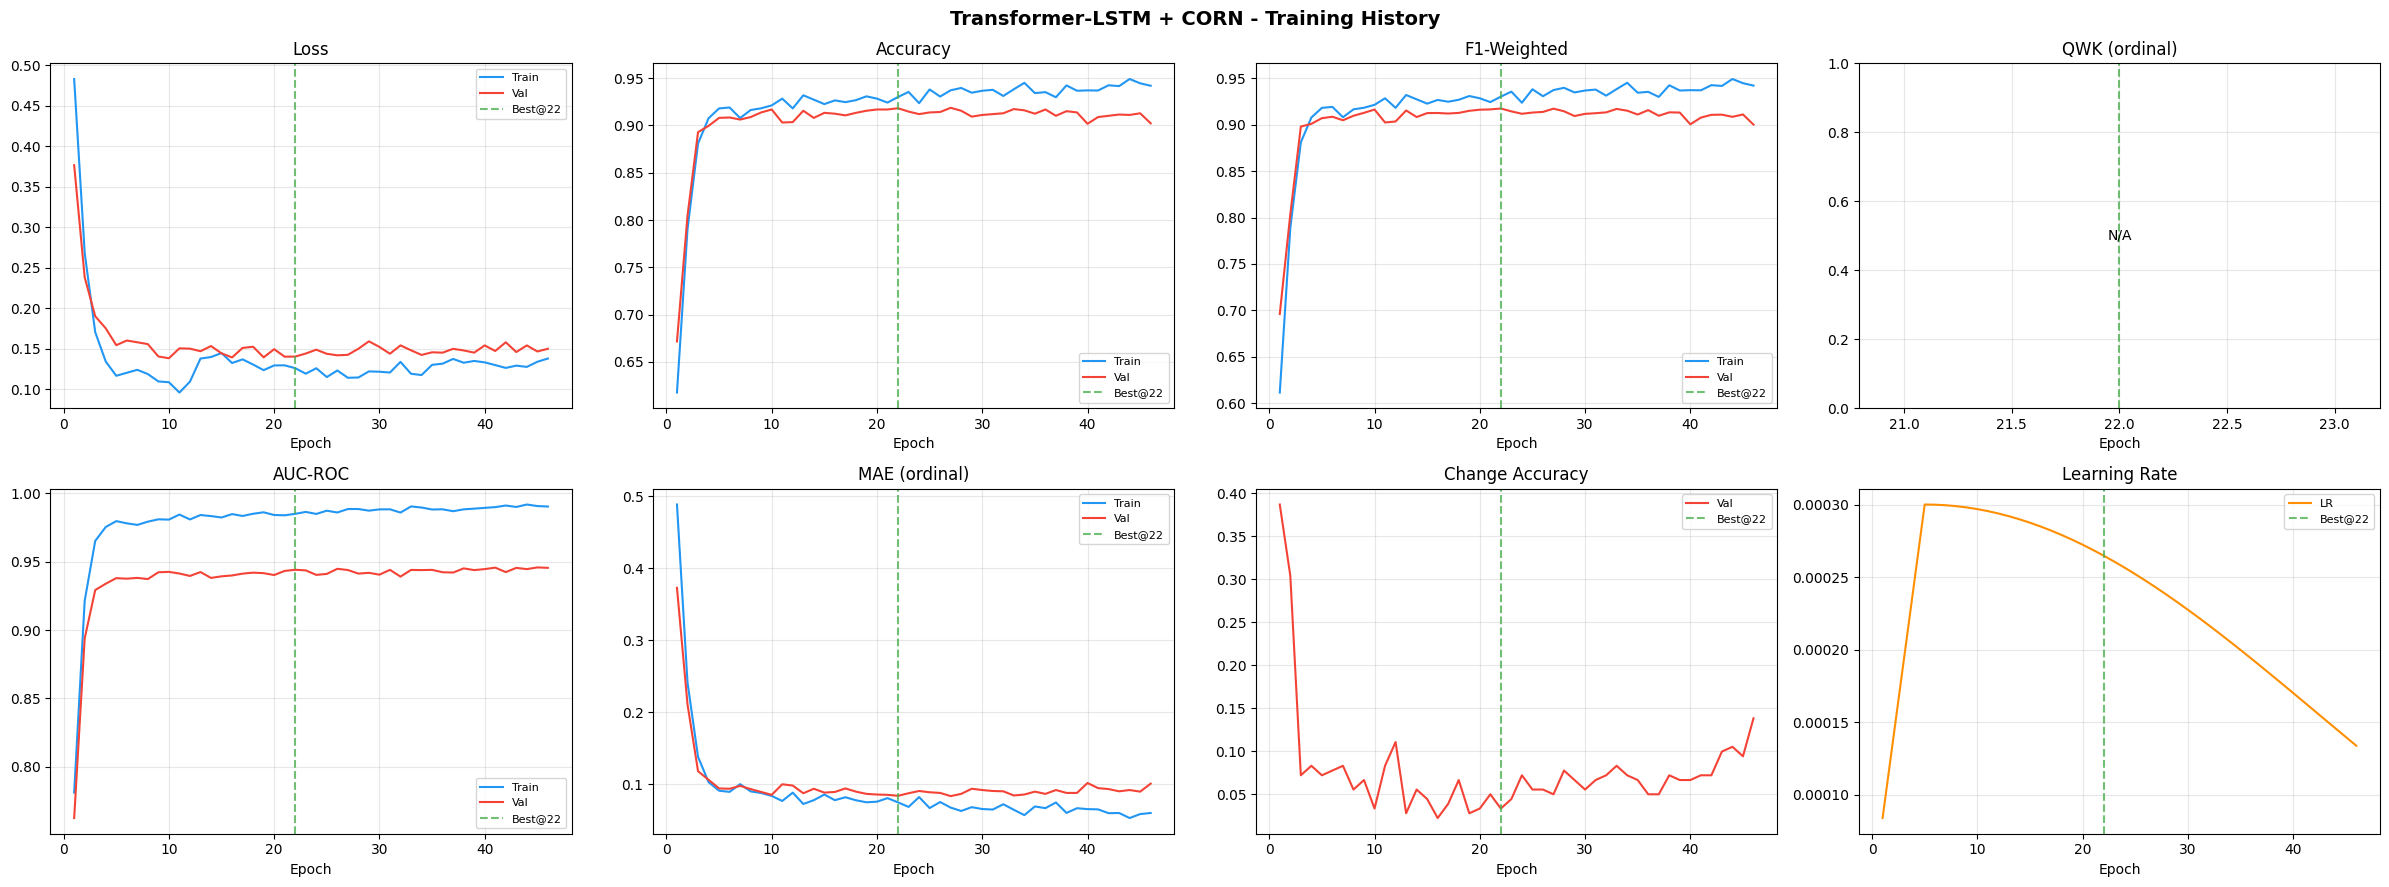

Saved metric curves figure -> metric_curves.png


In [ ]:
# ============================================================
# Visualization: Training Curves (Synced + Robust)
# ============================================================

epochs_x = list(range(1, len(history.get('train_loss', [])) + 1))
if len(epochs_x) == 0:
    raise ValueError('history is empty. Run training cell first.')

best_epoch_plot = int(globals().get('best_epoch', -1))

f1_train_key = 'train_f1_weighted' if 'train_f1_weighted' in history else 'train_f1'
f1_val_key = 'val_f1_weighted' if 'val_f1_weighted' in history else 'val_f1'
f1_title = 'F1-Weighted' if f1_train_key == 'train_f1_weighted' else 'F1-Macro'

if 'train_adj_acc' in history and 'val_adj_acc' in history:
    extra_title, extra_tr, extra_vl = 'Adjacent Accuracy (+/-1)', 'train_adj_acc', 'val_adj_acc'
elif 'val_change_acc' in history:
    extra_title, extra_tr, extra_vl = 'Change Accuracy', None, 'val_change_acc'
else:
    extra_title, extra_tr, extra_vl = 'Extra Metric', None, None

panels = [
    ('Loss',          'train_loss', 'val_loss'),
    ('Accuracy',      'train_acc', 'val_acc'),
    (f1_title,        f1_train_key, f1_val_key),
    ('QWK (ordinal)', 'train_qwk', 'val_qwk'),
    ('AUC-ROC',       'train_auc', 'val_auc'),
    ('MAE (ordinal)', 'train_mae', 'val_mae'),
    (extra_title,     extra_tr, extra_vl),
    ('Learning Rate', 'lr', None),
]

fig, axes = plt.subplots(2, 4, figsize=(24, 9))
fig.suptitle('Transformer-LSTM - Training History', fontsize=14, fontweight='bold')

for ax, (title, tr_key, vl_key) in zip(axes.flat, panels):
    has_curve = False

    if tr_key is not None and tr_key in history and len(history[tr_key]) > 0:
        tr_color = '#FF8F00' if tr_key == 'lr' else '#2196F3'
        tr_label = 'LR' if tr_key == 'lr' else 'Train'
        ax.plot(epochs_x, history[tr_key], color=tr_color, label=tr_label)
        has_curve = True

    if vl_key is not None and vl_key in history and len(history[vl_key]) > 0:
        ax.plot(epochs_x, history[vl_key], color='#F44336', label='Val')
        has_curve = True

    if best_epoch_plot > 0 and best_epoch_plot <= len(epochs_x):
        ax.axvline(best_epoch_plot, color='#4CAF50', linestyle='--', alpha=0.8, label=f'Best@{best_epoch_plot}')

    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.grid(alpha=0.3)

    if has_curve:
        ax.legend(fontsize=8)
    else:
        ax.text(0.5, 0.5, 'N/A', ha='center', va='center', transform=ax.transAxes)

plt.tight_layout()
plt.savefig(ARTIFACT_DIR / 'metric_curves.png', dpi=180, bbox_inches='tight')
plt.show()
print('Saved metric curves figure -> metric_curves.png')

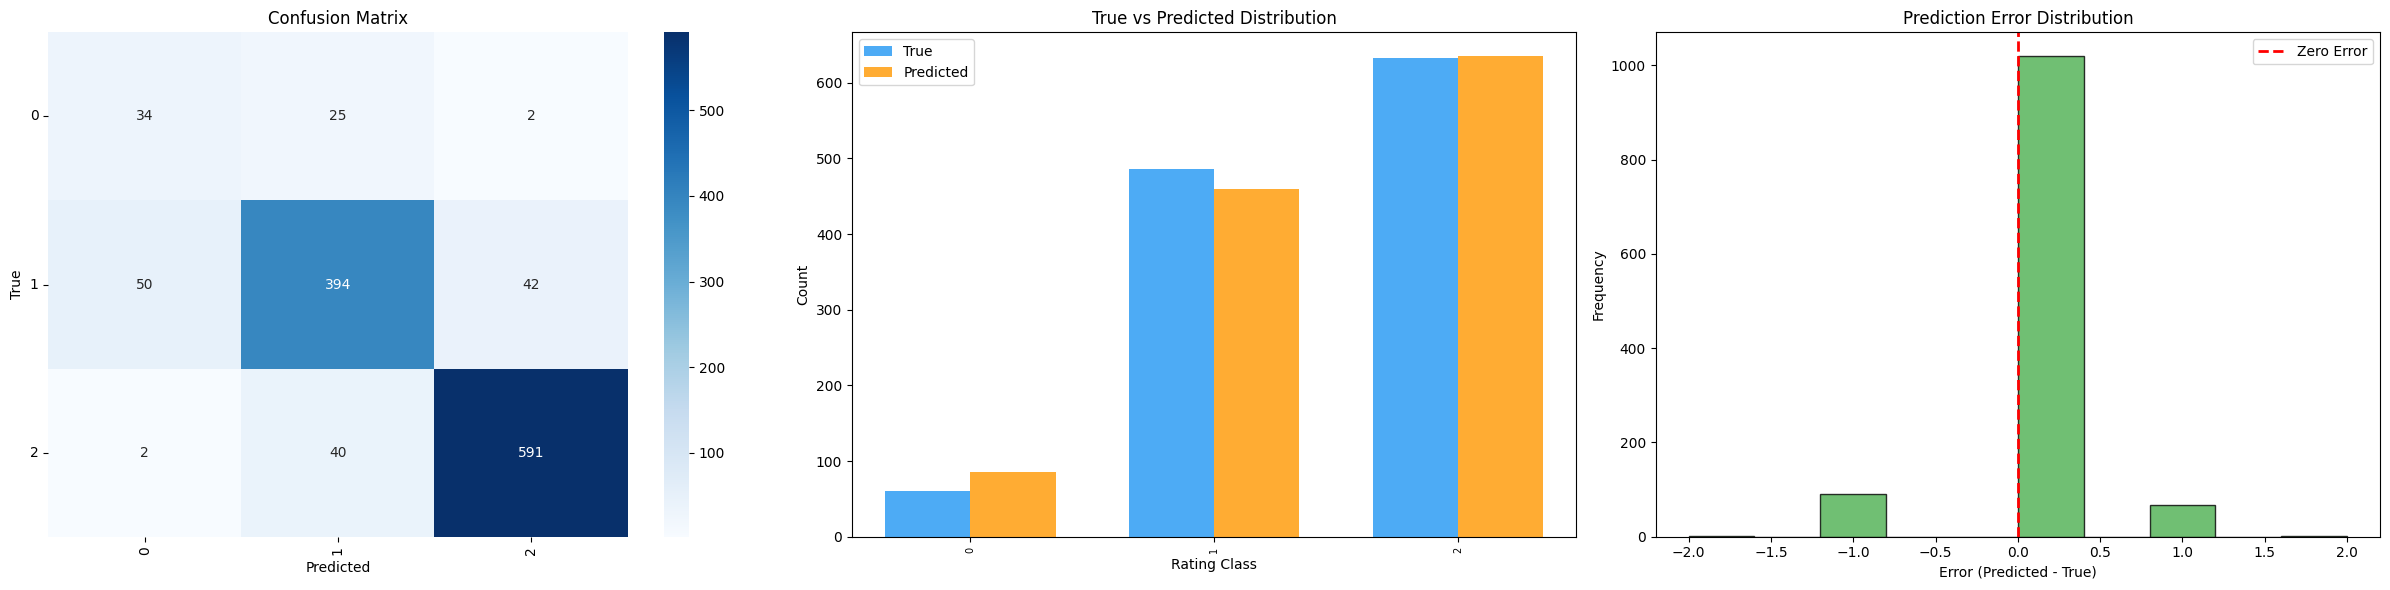

Result plots saved.


In [ ]:
# ============================================================
# Visualization: Confusion Matrix + Distributions
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(24, 6))

all_labels = sorted(set(y_true) | set(y_pred))
label_names = [str(i) for i in all_labels]
cm_display = confusion_matrix(y_true, y_pred, labels=all_labels)

if len(all_labels) <= 25:
    sns.heatmap(cm_display, annot=True, fmt='d', cmap='Blues',
                xticklabels=label_names, yticklabels=label_names, ax=axes[0])
else:
    sns.heatmap(cm_display, cmap='Blues', ax=axes[0])
axes[0].set_title('Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')
axes[0].tick_params(axis='x', rotation=90)
axes[0].tick_params(axis='y', rotation=0)

true_counts = pd.Series(y_true).value_counts().sort_index()
pred_counts = pd.Series(y_pred).value_counts().sort_index()
all_idx = sorted(set(true_counts.index) | set(pred_counts.index))
x_pos = np.arange(len(all_idx))
width = 0.35
axes[1].bar(x_pos - width/2, [true_counts.get(i, 0) for i in all_idx],
            width, label='True', alpha=0.8, color='#2196F3')
axes[1].bar(x_pos + width/2, [pred_counts.get(i, 0) for i in all_idx],
            width, label='Predicted', alpha=0.8, color='#FF9800')
axes[1].set_title('True vs Predicted Distribution')
axes[1].set_xlabel('Rating Class')
axes[1].set_ylabel('Count')
axes[1].legend()
if len(all_idx) <= 25:
    axes[1].set_xticks(x_pos)
    axes[1].set_xticklabels([str(i) for i in all_idx],
                             rotation=90, fontsize=7)

errors = y_pred - y_true
axes[2].hist(errors, bins=max(10, len(set(errors))), color='#4CAF50',
             edgecolor='black', alpha=0.8)
axes[2].set_title('Prediction Error Distribution')
axes[2].set_xlabel('Error (Predicted - True)')
axes[2].set_ylabel('Frequency')
axes[2].axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero Error')
axes[2].legend()

plt.tight_layout()
plt.savefig(ARTIFACT_DIR / 'transformer_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('Result plots saved.')

In [ ]:
# Build ticker-aligned result table for test predictions.
if 'test_seq_tickers' in globals() and len(test_seq_tickers) == len(y_true):
    result_tickers = np.asarray(test_seq_tickers, dtype=object)
else:
    # Safe fallback to avoid length mismatch if upstream cells were not re-run.
    result_tickers = np.array(['UNKNOWN'] * len(y_true), dtype=object)
    print(
        f"Warning: test_seq_tickers length mismatch "
        f"({len(globals().get('test_seq_tickers', []))} vs {len(y_true)}). "
        "Using UNKNOWN tickers."
    )

results = pd.DataFrame({
    'unique_id': result_tickers,
    'y_true_numeric': y_true,
    'y_pred_numeric': y_pred,
})

print('\n=== Sample Predictions ===')
print(f'{"Ticker":<10} {"True (num)":<15} {"Pred (num)":>15} {"Match":>8}')
print('-' * 54)

sample_n = min(30, len(results))
for _, row in results.head(sample_n).iterrows():
    match = 'Y' if row['y_true_numeric'] == row['y_pred_numeric'] else 'N'
    print(f'{row["unique_id"]:<10} '
          f'{int(row["y_true_numeric"]):<15} '
          f'{int(row["y_pred_numeric"]):>15} '
          f'{match:>8}')

print(f'\n=== Summary ===')
print(f'Total predictions: {len(results)}')
print(f'Correct: {(results["y_true_numeric"] == results["y_pred_numeric"]).sum()}')
print(f'Accuracy: {acc:.4f}')
print(f'F1 (weighted): {f1_weighted:.4f}')
if not np.isnan(auc_ovr):
    print(f'AUC-ROC (OvR): {auc_ovr:.4f}')
else:
    print('AUC-ROC: N/A')
print(f'\nAll artifacts saved to: {ARTIFACT_DIR.resolve()}')


=== Sample Predictions ===
Ticker     True (num)           Pred (num)    Match
------------------------------------------------------
AAPL       2                             2        Y
AAPL       2                             2        Y
AAPL       2                             2        Y
ABBV       2                             2        Y
ABC        2                             2        Y
ABEV       2                             2        Y
ABG        1                             2        N
ABT        2                             2        Y
ABT        2                             2        Y
ABT        2                             2        Y
ACCO       1                             1        Y
ACHC       1                             1        Y
ACM        1                             1        Y
ACM        1                             1        Y
ACN        2                             2        Y
ADM        2                             2        Y
ADM        2                     

## 11. xAI SHAP Interpretation

Giải thích dự đoán bằng SHAP (KernelExplainer) trên một tập con mẫu test.

Thiết kế cho bài toán time-series classification:
- Đầu vào SHAP là vector flatten của cửa sổ chuỗi (T x C).
- Mỗi mẫu được giải thích theo xác suất của lớp dự đoán.
- `last_y` và `sector_id` được giữ cố định theo từng mẫu để phản ánh ngữ cảnh thực tế.

Artifacts tạo thêm:
- `shap_feature_importance.csv`
- `shap_sample_explanations.csv`
- `shap_feature_importance.png`

Explaining predicted class probability for class: 2


  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/2 [00:00<?, ?it/s]

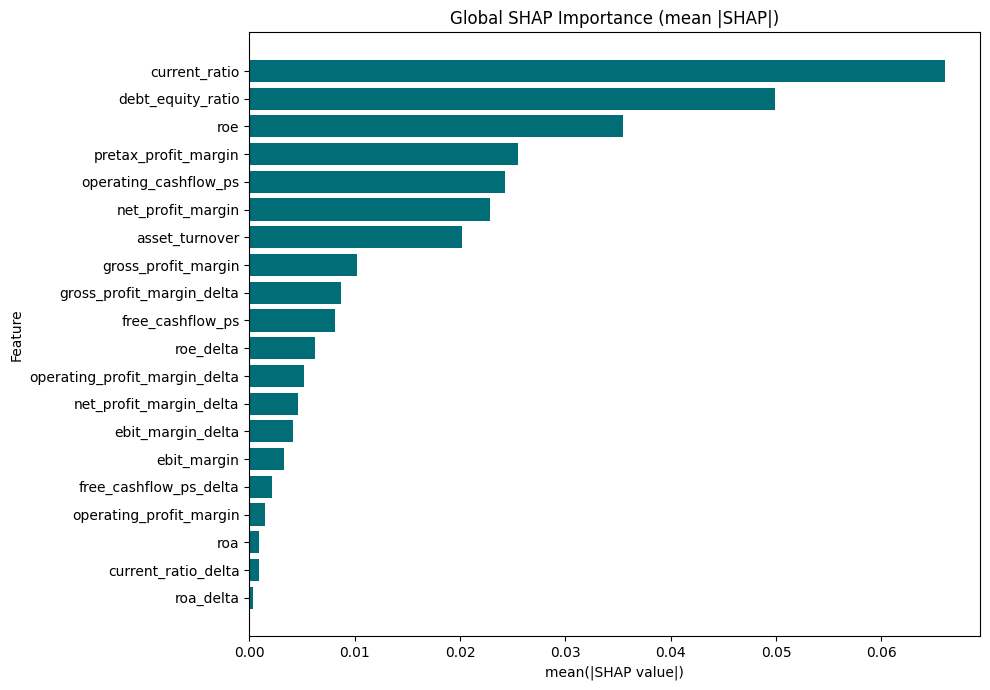

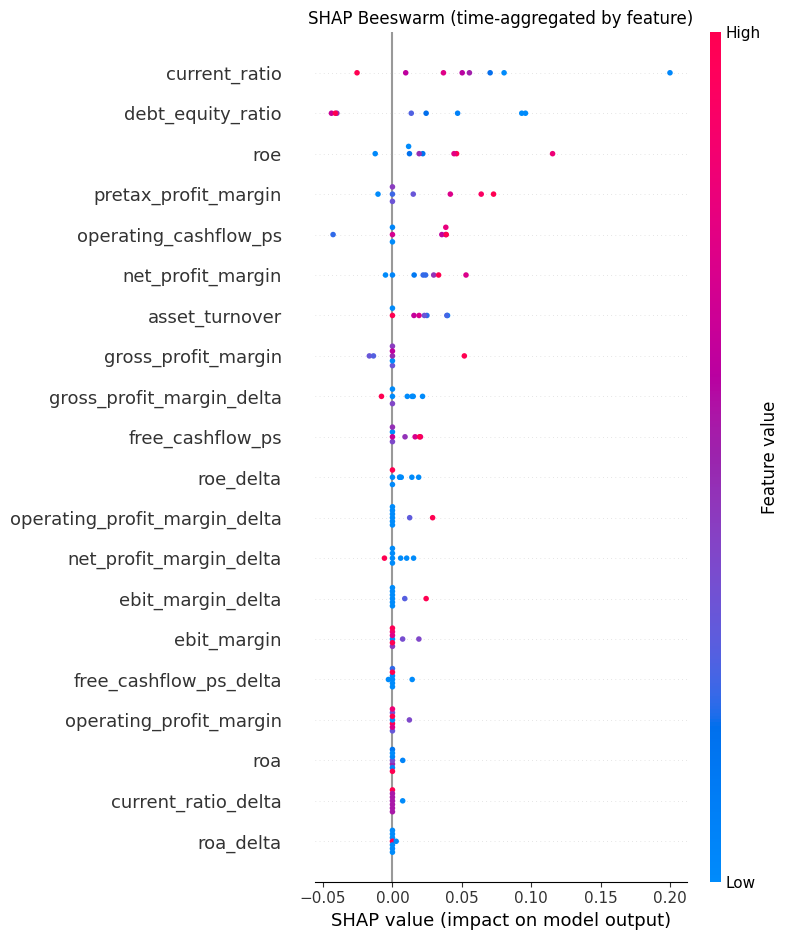

SHAP mode: fast | target: predicted_class
SHAP explained samples: 8
SHAP background windows: 80
SHAP nsamples (KernelExplainer): 120
Top SHAP features (global):
                      feature  mean_abs_shap
                current_ratio       0.066068
            debt_equity_ratio       0.049888
                          roe       0.035434
         pretax_profit_margin       0.025498
        operating_cashflow_ps       0.024254
            net_profit_margin       0.022836
               asset_turnover       0.020178
          gross_profit_margin       0.010270
    gross_profit_margin_delta       0.008673
             free_cashflow_ps       0.008140
                    roe_delta       0.006227
operating_profit_margin_delta       0.005171
Saved: /kaggle/working/credit_rating_artifacts/shap_feature_importance.csv
Saved: /kaggle/working/credit_rating_artifacts/shap_sample_explanations.csv
Saved: /kaggle/working/credit_rating_artifacts/shap_feature_importance.png
Saved: /kaggle/working/credi

In [ ]:
# ============================================================
# SHAP explainability for TLSTM-Fuzzy predictions (synced + robust)
# ============================================================

SHAP_ENABLED = True
SHAP_MODE = 'fast'            # {'fast', 'full'}
SHAP_TARGET = 'predicted_class'  # {'predicted_class', 'all_classes'}
SHAP_RANDOM_STATE = SEED

if SHAP_MODE == 'fast':
    SHAP_MAX_SAMPLES = 8
    SHAP_BACKGROUND_SIZE = 80
    SHAP_NSAMPLES = 120
else:
    SHAP_MAX_SAMPLES = 24
    SHAP_BACKGROUND_SIZE = 180
    SHAP_NSAMPLES = 240


if 'corn_logits_to_proba' not in globals():
    def corn_logits_to_proba(logits, n_classes, enforce_monotonic=True):
        q = torch.sigmoid(logits.float())
        if enforce_monotonic and q.shape[1] > 1:
            q = torch.cummin(q, dim=1)[0]
        eps = 1e-6
        q = q.clamp(eps, 1.0 - eps)
        probs = torch.zeros((q.shape[0], n_classes), device=q.device, dtype=q.dtype)
        probs[:, 0] = 1.0 - q[:, 0]
        if n_classes > 2:
            probs[:, 1:-1] = q[:, :-1] - q[:, 1:]
        probs[:, -1] = q[:, -1]
        probs = probs.clamp_min(eps)
        probs = probs / probs.sum(dim=1, keepdim=True)
        return probs


def _normalize_shap_output(shap_values, n_classes_expected):
    """
    Return (signed_2d, abs_2d) both with shape (N, F).
    Handles SHAP outputs as list or ndarray for binary/multiclass settings.
    """
    if isinstance(shap_values, list):
        if len(shap_values) == 0:
            raise ValueError('Empty SHAP list output.')
        arr = np.stack([np.asarray(v) for v in shap_values], axis=0)  # (K, N, F)
        signed_2d = arr.mean(axis=0)
        abs_2d = np.mean(np.abs(arr), axis=0)
        return np.asarray(signed_2d), np.asarray(abs_2d)

    arr = np.asarray(shap_values)
    if arr.ndim == 1:
        arr = arr.reshape(1, -1)
        return arr, np.abs(arr)

    if arr.ndim == 2:
        return arr, np.abs(arr)

    if arr.ndim == 3:
        if arr.shape[-1] == n_classes_expected:
            signed_2d = arr.mean(axis=2)
            abs_2d = np.mean(np.abs(arr), axis=2)
            return signed_2d, abs_2d
        if arr.shape[0] == n_classes_expected:
            signed_2d = arr.mean(axis=0)
            abs_2d = np.mean(np.abs(arr), axis=0)
            return signed_2d, abs_2d

        signed_2d = arr.mean(axis=0)
        abs_2d = np.mean(np.abs(arr), axis=0)
        return signed_2d, abs_2d

    raise ValueError(f'Unsupported SHAP output ndim={arr.ndim}')


if SHAP_ENABLED:
    try:
        import shap
    except Exception:
        import subprocess
        import sys
        print('Installing shap package...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'shap', '-q'])
        import shap

    rng = np.random.default_rng(SHAP_RANDOM_STATE)

    if len(train_seqs) == 0 or len(test_seqs) == 0:
        raise ValueError('SHAP requires non-empty train_seqs and test_seqs. Re-run previous cells first.')

    train_X_all = np.stack([s[0] for s in train_seqs], axis=0).astype(np.float32)
    test_X_all = np.stack([s[0] for s in test_seqs], axis=0).astype(np.float32)
    test_last_y_all = np.array([s[1] for s in test_seqs], dtype=int)
    test_sector_all = np.array([s[2] for s in test_seqs], dtype=int)
    test_target_all = np.array([s[3] for s in test_seqs], dtype=int)

    has_tickers = ('test_seq_tickers' in globals()) and (len(test_seq_tickers) == len(test_seqs))

    background_size = int(min(SHAP_BACKGROUND_SIZE, len(train_X_all)))
    explain_size = int(min(SHAP_MAX_SAMPLES, len(test_X_all)))

    if background_size <= 0 or explain_size <= 0:
        raise ValueError('Not enough samples to run SHAP. Check train/test split cells.')

    bg_idx = rng.choice(len(train_X_all), size=background_size, replace=False)
    explain_idx = rng.choice(len(test_X_all), size=explain_size, replace=False)

    background_flat = train_X_all[bg_idx].reshape(background_size, -1)
    explain_seqs = test_X_all[explain_idx]  # (N, T, C)
    explain_flat = explain_seqs.reshape(explain_size, -1)
    explain_last_y = test_last_y_all[explain_idx]
    explain_sector = test_sector_all[explain_idx]

    n_features_flat = background_flat.shape[1]
    if n_features_flat != INPUT_SIZE * n_channels:
        raise ValueError(
            f'SHAP flat feature mismatch: got {n_features_flat}, expected {INPUT_SIZE * n_channels}.'
        )

    timestep_labels = [f't-{INPUT_SIZE - 1 - t}' for t in range(INPUT_SIZE)]
    flat_feature_names = [
        f'{step}__{feat}'
        for step in timestep_labels
        for feat in MODEL_FEATURES
    ]

    model.eval()

    def _predict_proba_with_context(x_flat_batch, last_y_value, sector_value):
        x_flat_batch = np.asarray(x_flat_batch, dtype=np.float32)
        if x_flat_batch.ndim == 1:
            x_flat_batch = x_flat_batch.reshape(1, -1)

        x_batch = torch.tensor(
            x_flat_batch.reshape(-1, INPUT_SIZE, n_channels),
            dtype=torch.float32,
            device=device,
        )
        ly_batch = torch.full(
            (x_batch.shape[0],),
            fill_value=int(last_y_value),
            dtype=torch.long,
            device=device,
        )
        sec_batch = torch.full(
            (x_batch.shape[0],),
            fill_value=int(sector_value),
            dtype=torch.long,
            device=device,
        )

        with torch.no_grad():
            logits = model(x_batch, ly_batch, sec_batch)
            if logits.shape[1] == n_classes - 1:
                probs = corn_logits_to_proba(logits, n_classes=n_classes)
            else:
                probs = torch.softmax(logits, dim=1)
        return probs.detach().cpu().numpy()

    # Predict explained samples once using their real contexts.
    with torch.no_grad():
        x_tensor = torch.tensor(explain_seqs, dtype=torch.float32, device=device)
        ly_tensor = torch.tensor(explain_last_y, dtype=torch.long, device=device)
        sec_tensor = torch.tensor(explain_sector, dtype=torch.long, device=device)
        logits_explain = model(x_tensor, ly_tensor, sec_tensor)
        if logits_explain.shape[1] == n_classes - 1:
            probs_explain = corn_logits_to_proba(logits_explain, n_classes=n_classes).cpu().numpy()
        else:
            probs_explain = torch.softmax(logits_explain, dim=1).cpu().numpy()

    y_pred_explain = probs_explain.argmax(axis=1)
    pred_prob_explain = probs_explain[np.arange(explain_size), y_pred_explain]

    if SHAP_TARGET == 'predicted_class':
        target_class = int(np.bincount(y_pred_explain, minlength=n_classes).argmax())
        print(f'Explaining predicted class probability for class: {target_class}')
    else:
        target_class = -1
        print('Explaining all classes and averaging SHAP magnitudes across classes.')

    # Group by context (last_y, sector_id) to keep contextual variables fixed during SHAP.
    context_to_positions = {}
    for sample_pos, (ly_i, sec_i) in enumerate(zip(explain_last_y, explain_sector)):
        key = (int(ly_i), int(sec_i))
        context_to_positions.setdefault(key, []).append(sample_pos)

    rows_feature_imp = []
    rows_detail = []
    agg_signed_feature = []
    agg_feature_values = []

    for (ly_i, sec_i), sample_positions in sorted(context_to_positions.items()):
        local_flat = explain_flat[sample_positions]

        if SHAP_TARGET == 'predicted_class':
            predict_fn = lambda x, ly=ly_i, sec=sec_i: _predict_proba_with_context(x, ly, sec)[:, target_class]
        else:
            predict_fn = lambda x, ly=ly_i, sec=sec_i: _predict_proba_with_context(x, ly, sec)

        explainer = shap.KernelExplainer(
            model=predict_fn,
            data=background_flat,
            link='identity',
        )
        shap_raw = explainer.shap_values(local_flat, nsamples=SHAP_NSAMPLES)
        signed_local, abs_local = _normalize_shap_output(shap_raw, n_classes)

        if signed_local.shape != local_flat.shape:
            raise ValueError(
                f'SHAP shape mismatch for context {(ly_i, sec_i)}: {signed_local.shape} vs {local_flat.shape}'
            )

        for local_i, sample_pos in enumerate(sample_positions):
            global_test_index = int(explain_idx[sample_pos])
            y_true_i = int(test_target_all[global_test_index])
            y_pred_i = int(y_pred_explain[sample_pos])
            pred_prob_i = float(pred_prob_explain[sample_pos])
            ticker_i = str(test_seq_tickers[global_test_index]) if has_tickers else 'UNKNOWN'

            sample_abs = abs_local[local_i]
            sample_signed = signed_local[local_i]

            abs_matrix = sample_abs.reshape(INPUT_SIZE, n_channels)
            signed_matrix = sample_signed.reshape(INPUT_SIZE, n_channels)
            feature_abs = abs_matrix.mean(axis=0)
            feature_signed = signed_matrix.mean(axis=0)

            agg_signed_feature.append(feature_signed)
            agg_feature_values.append(explain_seqs[sample_pos].mean(axis=0))

            for feat, imp in zip(MODEL_FEATURES, feature_abs):
                rows_feature_imp.append({
                    'sample_rank': int(sample_pos + 1),
                    'sample_index': int(global_test_index),
                    'ticker': ticker_i,
                    'y_true': y_true_i,
                    'y_pred': y_pred_i,
                    'pred_prob': pred_prob_i,
                    'target_class_explained': int(target_class),
                    'last_y_context': int(ly_i),
                    'sector_id': int(sec_i),
                    'feature': str(feat),
                    'mean_abs_shap': float(imp),
                })

            topk = int(min(8, len(flat_feature_names)))
            top_pos = np.argsort(-sample_abs)[:topk]
            for p in top_pos:
                rows_detail.append({
                    'sample_rank': int(sample_pos + 1),
                    'sample_index': int(global_test_index),
                    'ticker': ticker_i,
                    'y_true': y_true_i,
                    'y_pred': y_pred_i,
                    'pred_prob': pred_prob_i,
                    'target_class_explained': int(target_class),
                    'feature_flat': flat_feature_names[p],
                    'feature_value': float(local_flat[local_i, p]),
                    'shap_value': float(sample_signed[p]),
                    'abs_shap_value': float(sample_abs[p]),
                    'last_y_context': int(ly_i),
                    'sector_id': int(sec_i),
                })

    shap_feature_df = pd.DataFrame(rows_feature_imp)
    shap_detail_df = pd.DataFrame(rows_detail)

    if len(shap_feature_df) == 0:
        raise ValueError('No SHAP explanations were generated. Check SHAP settings and rerun.')

    shap_global = (
        shap_feature_df.groupby('feature', as_index=False)['mean_abs_shap']
        .mean()
        .sort_values('mean_abs_shap', ascending=False)
        .reset_index(drop=True)
    )

    shap_feature_path = ARTIFACT_DIR / 'shap_feature_importance.csv'
    shap_detail_path = ARTIFACT_DIR / 'shap_sample_explanations.csv'
    shap_bar_path = ARTIFACT_DIR / 'shap_feature_importance.png'
    shap_beeswarm_path = ARTIFACT_DIR / 'shap_beeswarm.png'

    shap_global.to_csv(shap_feature_path, index=False)
    shap_detail_df.to_csv(shap_detail_path, index=False)

    plt.figure(figsize=(10, 7))
    top_plot = shap_global.head(20).iloc[::-1]
    plt.barh(top_plot['feature'], top_plot['mean_abs_shap'], color='#006D77')
    plt.title('Global SHAP Importance (mean |SHAP|)')
    plt.xlabel('mean(|SHAP value|)')
    plt.ylabel('Feature')
    plt.tight_layout()
    plt.savefig(shap_bar_path, dpi=180, bbox_inches='tight')
    plt.show()

    if len(agg_signed_feature) > 0:
        agg_signed_feature = np.vstack(agg_signed_feature)
        agg_feature_values = np.vstack(agg_feature_values)

        plt.figure(figsize=(12, 8))
        shap.summary_plot(
            agg_signed_feature,
            agg_feature_values,
            feature_names=MODEL_FEATURES,
            show=False,
        )
        plt.title('SHAP Beeswarm (time-aggregated by feature)')
        plt.tight_layout()
        plt.savefig(shap_beeswarm_path, dpi=180, bbox_inches='tight')
        plt.show()

    print(f'SHAP mode: {SHAP_MODE} | target: {SHAP_TARGET}')
    print(f'SHAP explained samples: {explain_size}')
    print(f'SHAP background windows: {background_size}')
    print(f'SHAP nsamples (KernelExplainer): {SHAP_NSAMPLES}')
    print('Top SHAP features (global):')
    print(shap_global.head(12).to_string(index=False))
    print(f'Saved: {shap_feature_path}')
    print(f'Saved: {shap_detail_path}')
    print(f'Saved: {shap_bar_path}')
    print(f'Saved: {shap_beeswarm_path}')
else:
    print('SHAP is disabled. Set SHAP_ENABLED=True to run explanations.')

## Summary

**Model:** Transformer-LSTM Classifier with Fuzzy feature expansion + Sector Embedding

**Data & Split Guardrails (updated):**
- Có cờ `ENFORCE_TICKER_DISJOINT` để kiểm soát rò rỉ ticker giữa train/val/test
- In thống kê overlap ticker trước khi train để giám sát độ tin cậy đánh giá

**Target Pipeline (updated):**
- Mapping nhãn động theo dữ liệu quan sát được (không fix cứng 22 lớp)
- Hỗ trợ cả nhãn số và nhãn chuỗi (ví dụ Distressed/HY/IG)
- `n_classes` được suy ra đúng theo tập hiện tại

**Loss (updated):**
- Focal + Ordinal + Class-Balanced Effective Number Weighting
- Tăng trọng số học cho lớp thiểu số nhưng vẫn giữ ổn định lớp đa số

**Calibration (new):**
- Quét threshold lớp thiểu số trên tập validation
- Chọn threshold theo score: `macro_F1 + 0.20 * recall_class0`
- Áp dụng threshold ở test inference để cải thiện macro-F1/recall lớp thiểu số

**Feature Engineering:**
- Global scaling bằng `RobustScaler` (fit trên train split)
- Mở rộng input bằng các đặc trưng delta theo thời gian (`feature_t - feature_t-1`)
- Bổ sung `sector_id` qua embedding và concat vào vector phân loại cuối

**Architecture:**
FuzzyLayer -> Linear projection -> Multi-head self-attention blocks với relative positional bias -> BiLSTM -> Attentive pooling -> concat(last_y embedding, sector embedding) -> Classification Head

**xAI (SHAP):**
- Dùng `shap.KernelExplainer` để giải thích xác suất lớp dự đoán trên các mẫu test
- Tổng hợp global importance theo feature từ chuỗi thời gian flatten

**Artifacts:**
- `transformer_best_model.pt`, `transformer_best_model_meta.pt`
- `transformer_metrics.csv`, `transformer_metrics_n{n_classes}.csv`
- `metric_curves.png`, `transformer_results.png`
- `shap_feature_importance.csv`, `shap_sample_explanations.csv`, `shap_feature_importance.png`